# Exploratory Data Analysis - PS-S06E09: Electric Vehicle Purchases

This notebook performs exploratory data analysis (EDA) for **Playground Series Season 6 Episode 9**, focusing on predicting the binary target variable `Will_Buy_EV` (`Yes` / `No`).

We investigate dataset structure, missing values, class distributions, feature drift between training and testing sets, and evaluate feature signal strengths using Spearman correlations and target rate breakdowns.

## 1. Approach & Setup

We follow a structured EDA workflow:
1. **Sweetviz Automated Profiling**: Generate HTML profile reports for train vs test drift, feature distributions, and target breakdown.
2. **Target-Aware Visualizations**: Run custom plots (`DataVisualizer`) to inspect feature distributions against `Will_Buy_EV`.
3. **Train vs Test KDE Analysis**: Inspect continuous numerical feature distributions across train and test splits to confirm zero distribution shift.
4. **Original Data Inspection**: Evaluate similarities between synthetic competition data and original reference dataset.

### Install Automated Profiling Tools

In [1]:
%pip -q install --upgrade sweetviz

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
import sweetviz as sv
import scipy.stats as st
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e09_experiment_setup import ExperimentSetup
from ps_s06e09_data_visualization import DataVisualizer

# --- Notebook settings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
setup = ExperimentSetup()

# Seed pandas, numpy, and python built-ins
seed = setup.set_seeds()

setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'Will_Buy_EV'

Random seed set to: 10301
Warnings suppressed.


## 2. Load Datasets

In [4]:
training_df = setup.read_dataset('training')
original_df = setup.read_dataset('original')

TRAINING DATASET

   id  Age  Annual_Income_USD  Daily_Commute_km  Number_of_Cars_Owned  \
0   0   66         92,887.000            23.400                     2   
1   1   38         30,000.000             5.000                     1   
2   2   26         94,389.000            36.800                     1   
3   3   66         73,580.000            23.700                     2   
4   4   54         57,898.000            50.800                     1   

   Charging_Stations_Near_Home  Charging_Stations_Near_Work  \
0                            3                            7   
1                            2                            2   
2                            8                           15   
3                            6                            9   
4                            2                            3   

   Environmental_Concern_Level  Gender City_Type Current_Car_Type  \
0                        1.000    Male  Suburban            Sedan   
1                        4

### Target Class Distribution Insights

* **Imbalance**: The target `Will_Buy_EV` is significantly imbalanced:
  * **No**: ~82.5% (551,886 samples)
  * **Yes**: ~17.5% (116,779 samples)
* **Implication**: Baseline accuracy is 82.5%. Evaluation uses **ROC AUC**, which evaluates probability ranking. Stratified K-Fold cross-validation is required to maintain consistent target ratios across all folds.

In [5]:
test_df = setup.read_dataset('test')

TEST DATASET

       id  Age  Annual_Income_USD  Daily_Commute_km  Number_of_Cars_Owned  \
0  668665   61         67,725.000            16.900                     2   
1  668666   42        152,835.000            41.900                     2   
2  668667   68         86,877.000            53.300                     1   
3  668668   39         46,794.000            34.100                     2   
4  668669   55        112,172.000            57.200                     1   

   Charging_Stations_Near_Home  Charging_Stations_Near_Work  \
0                            7                            4   
1                            9                            9   
2                           10                           11   
3                            4                            8   
4                            6                            4   

   Environmental_Concern_Level  Gender City_Type Current_Car_Type  \
0                        4.000    Male  Suburban            Sedan   
1     

## 3. Sweetviz Automated Reports

### Train vs Test Comparison

Generates a comparison report to spot any feature distribution drift between training and test sets.

                                             |                                                                …

Report sweetviz_train_test.html was generated.



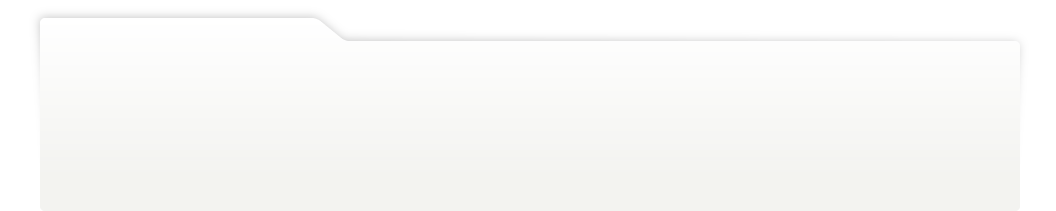
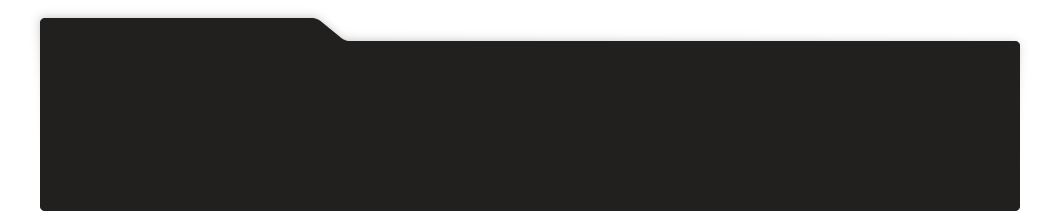
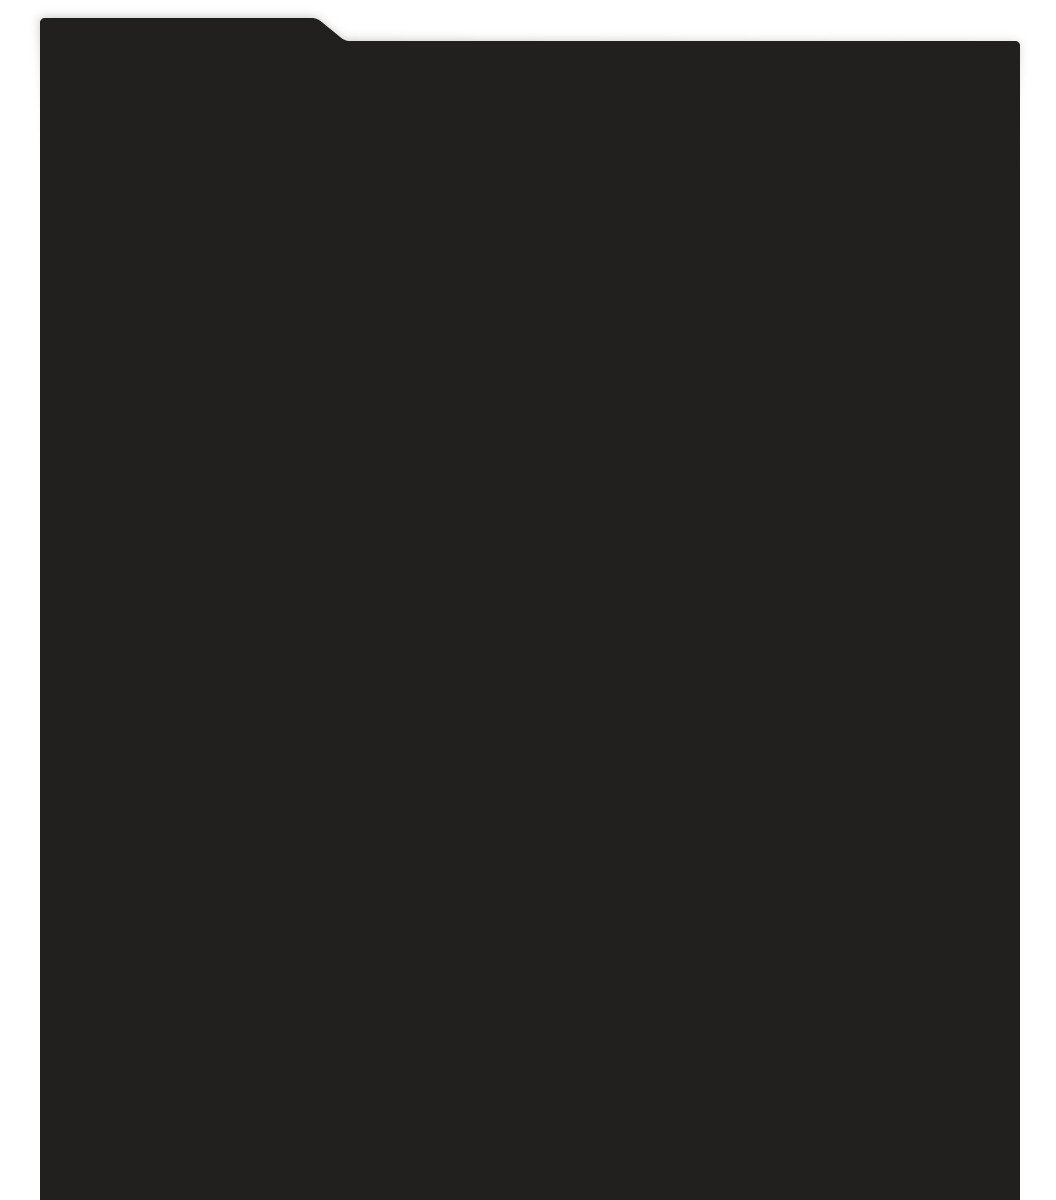
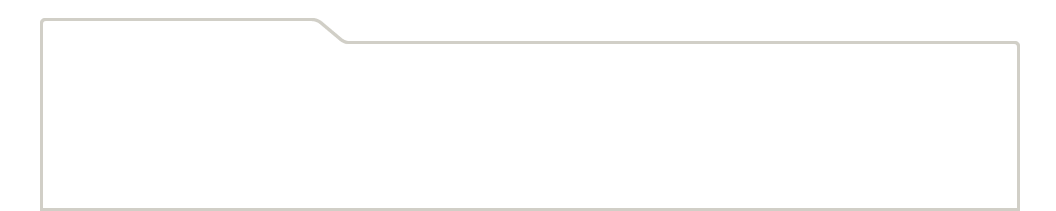
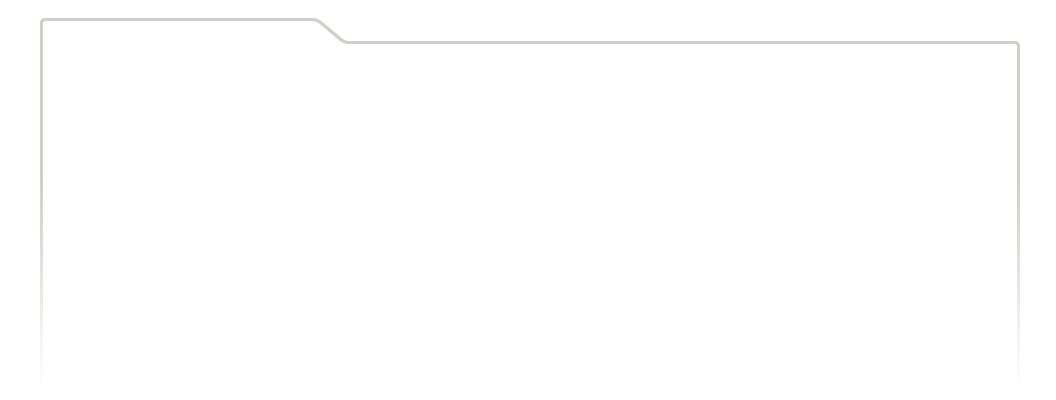
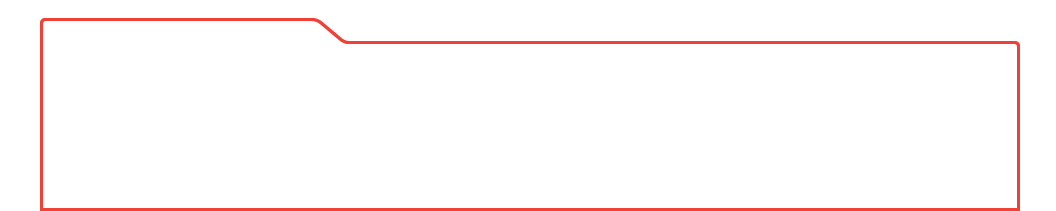
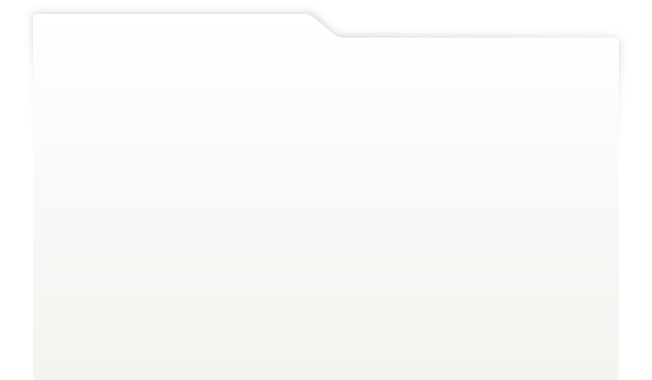
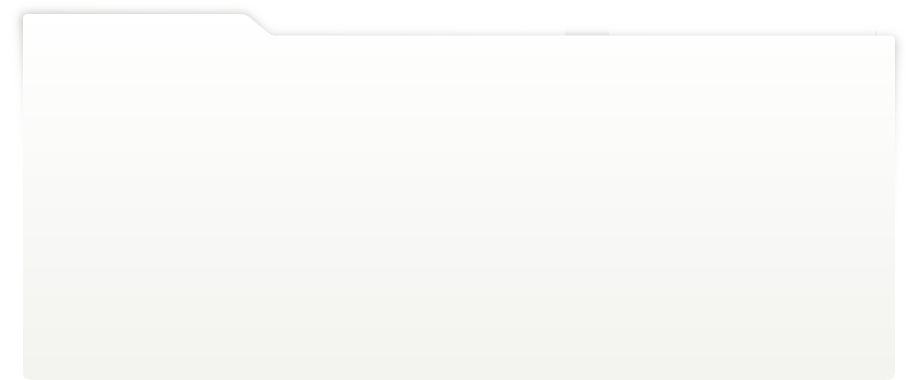
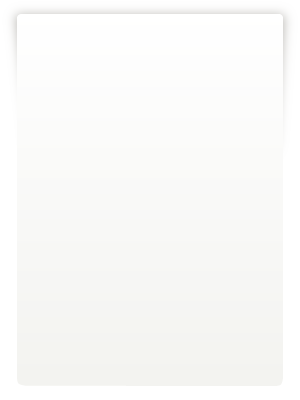
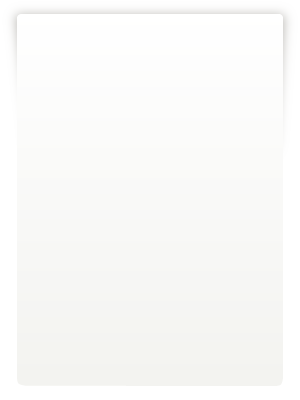
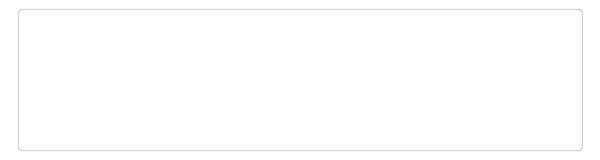
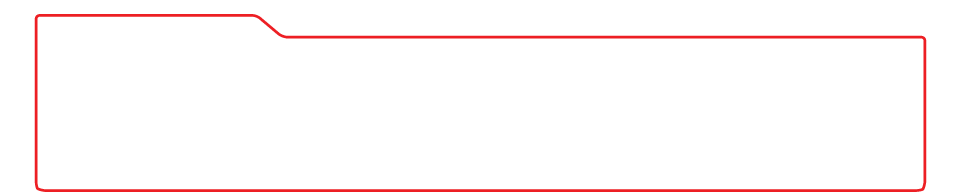
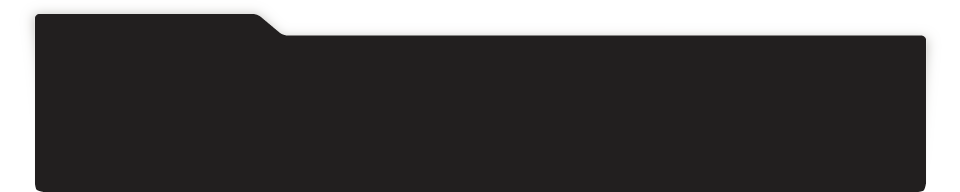
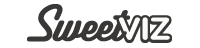
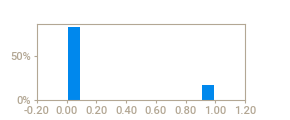
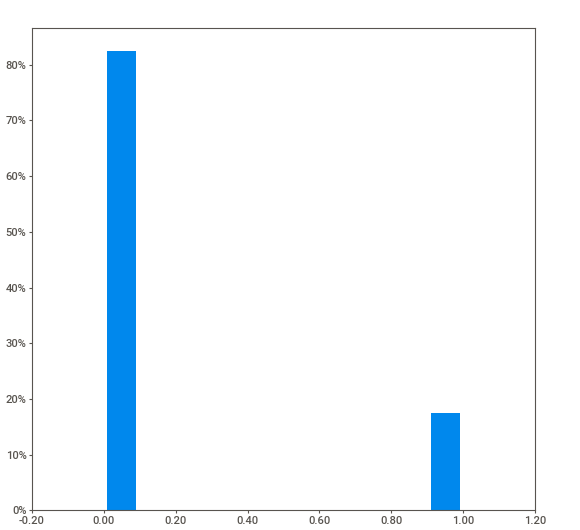
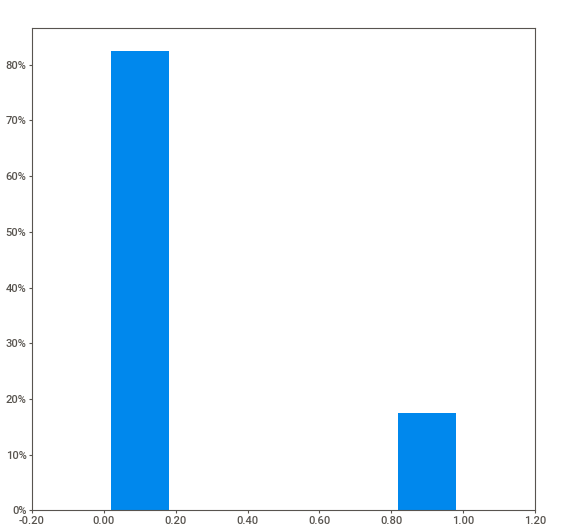
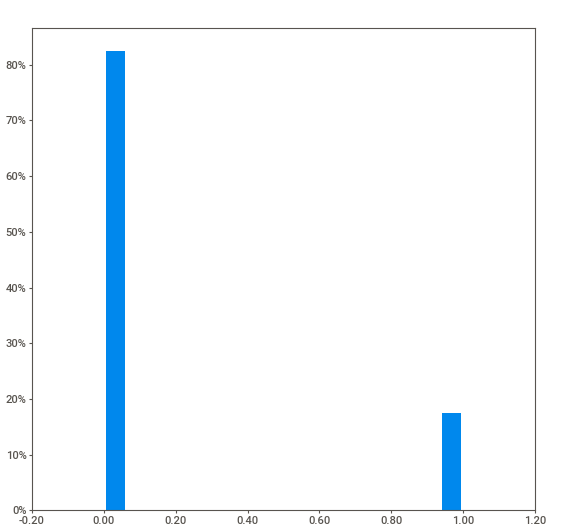
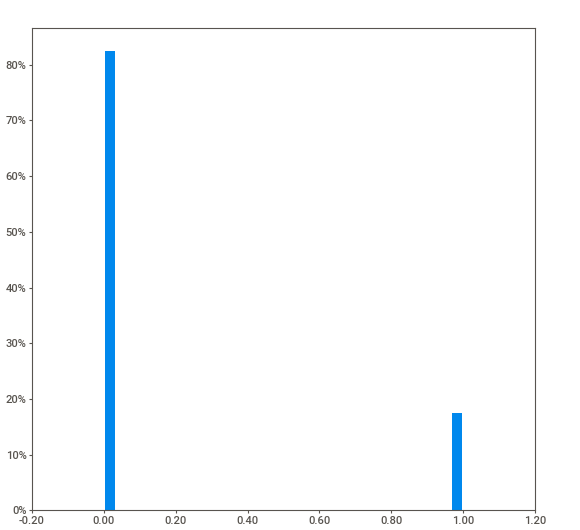
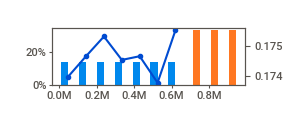
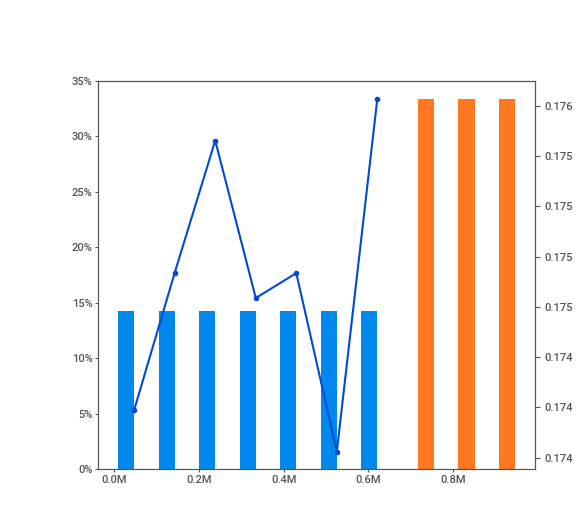
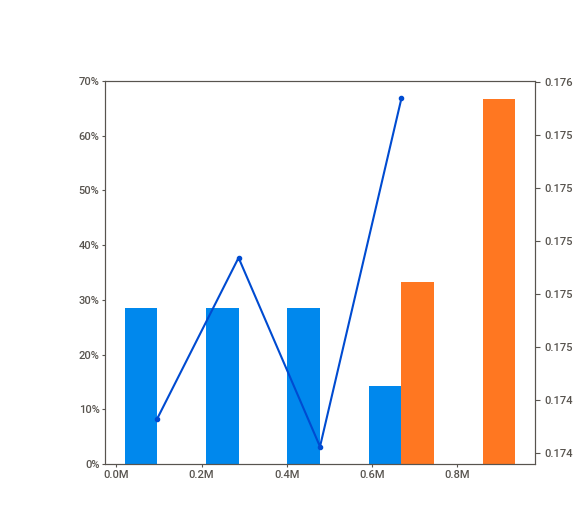
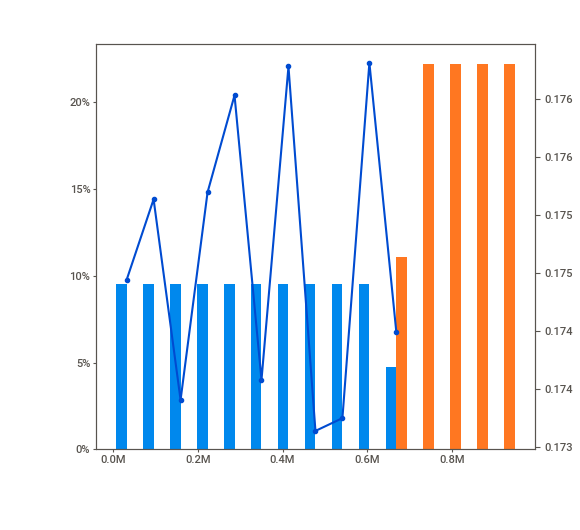
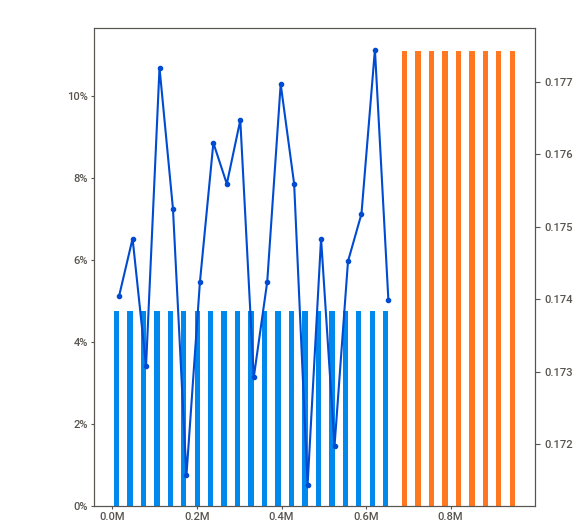
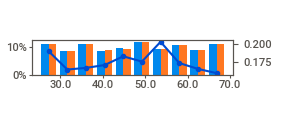
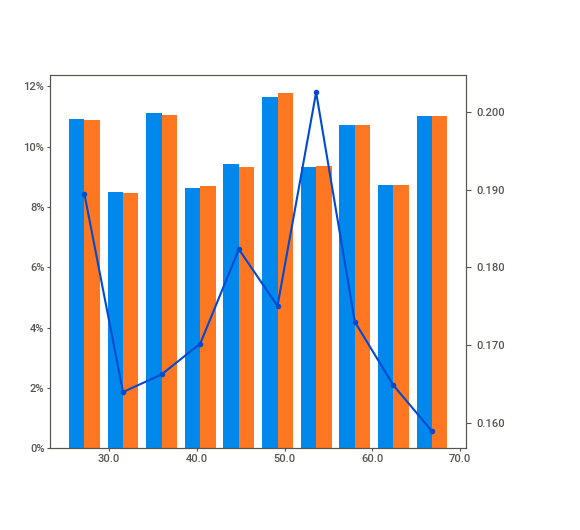
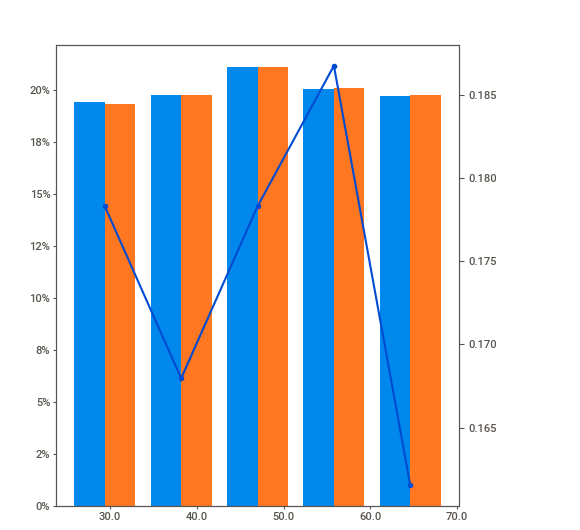
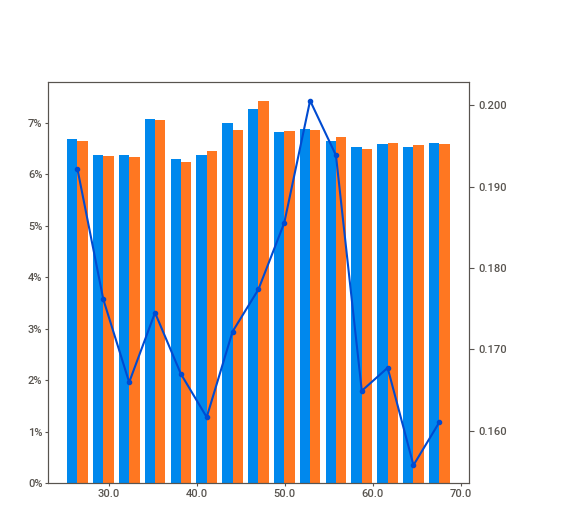
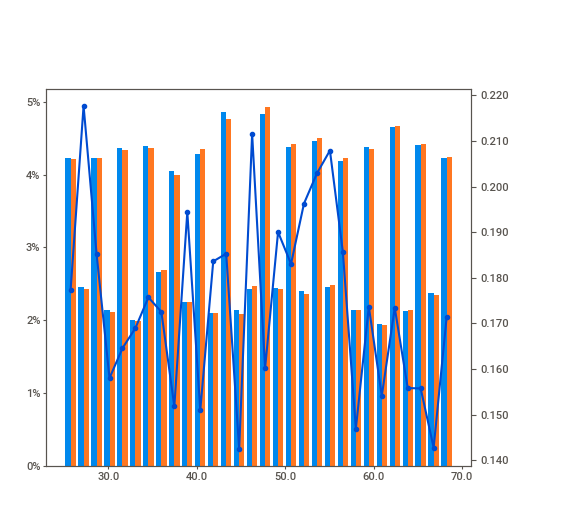
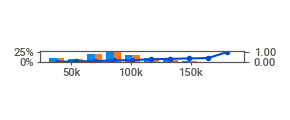
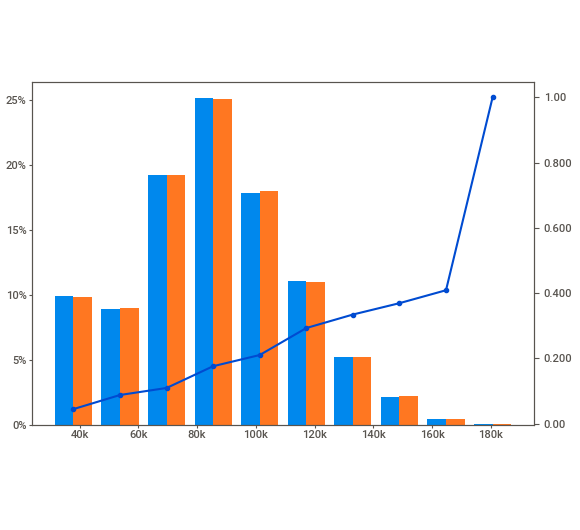
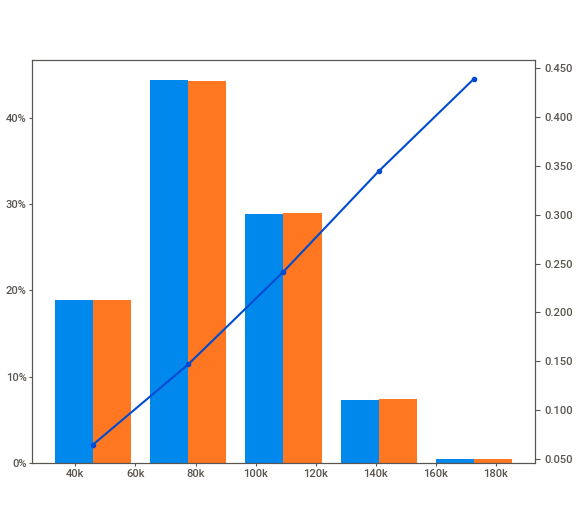
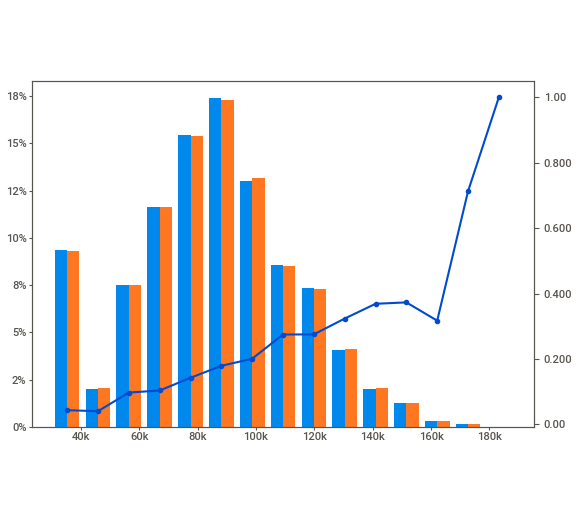
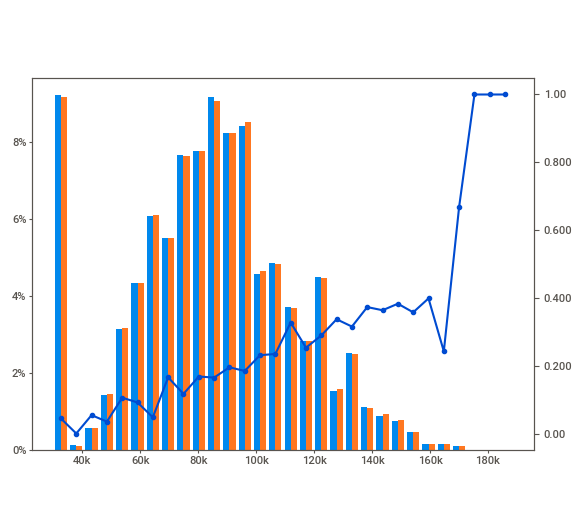
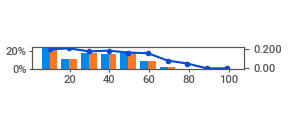
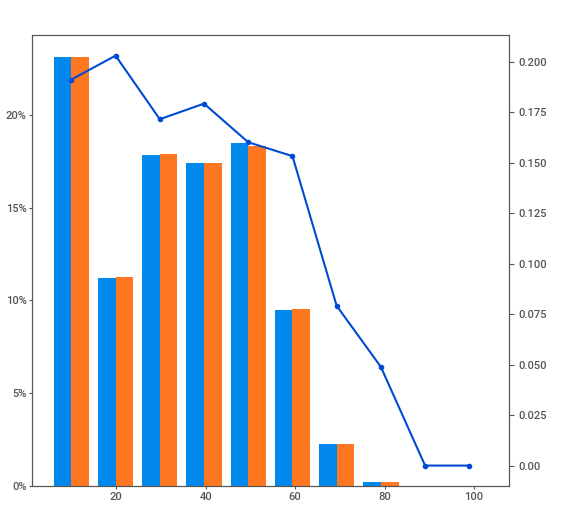
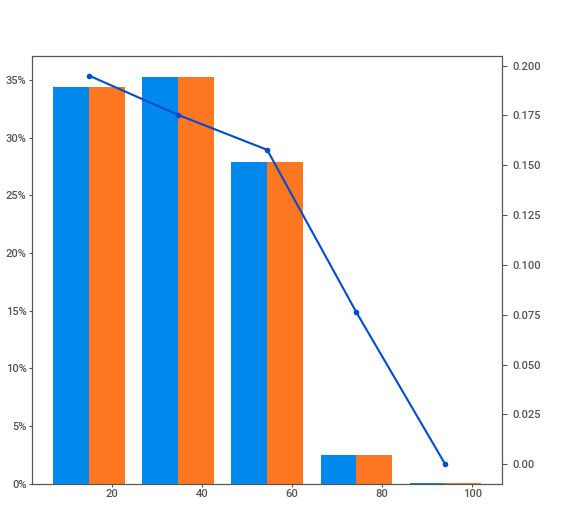
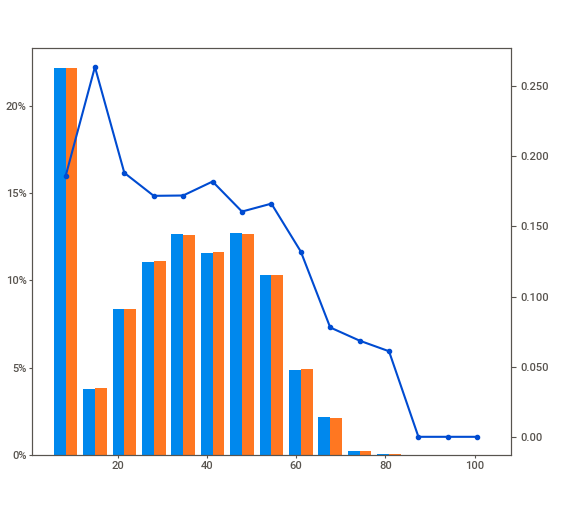
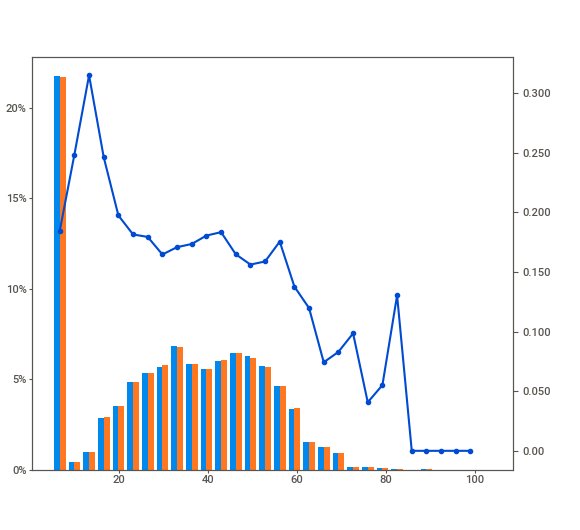
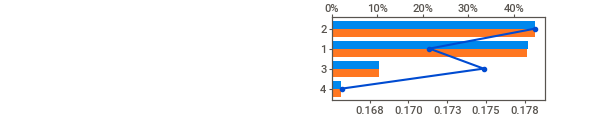
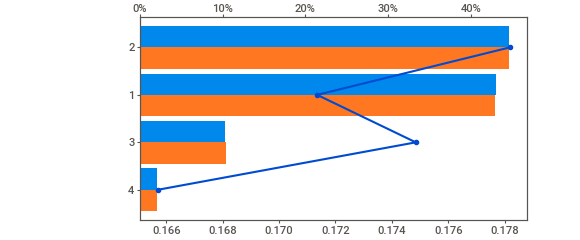
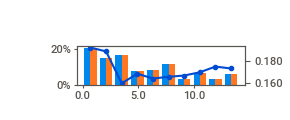
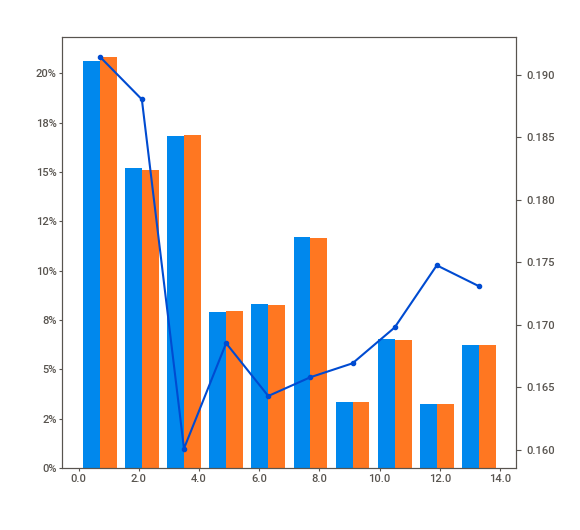
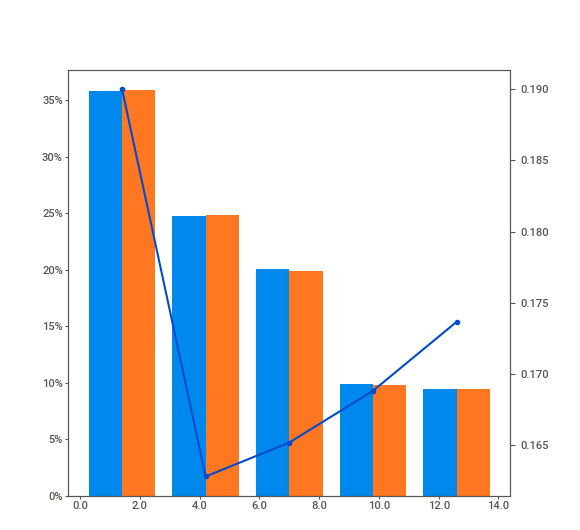
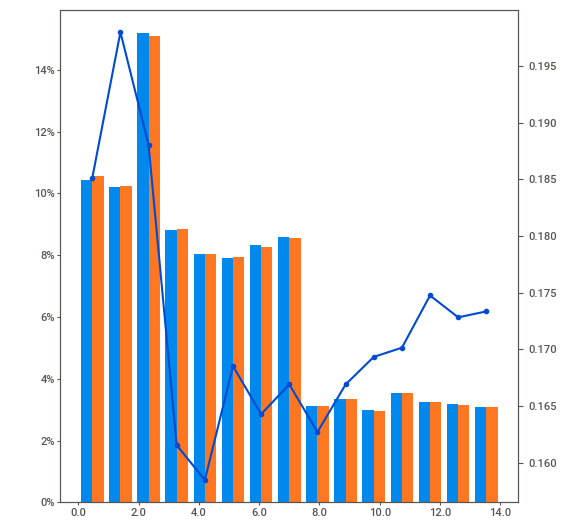
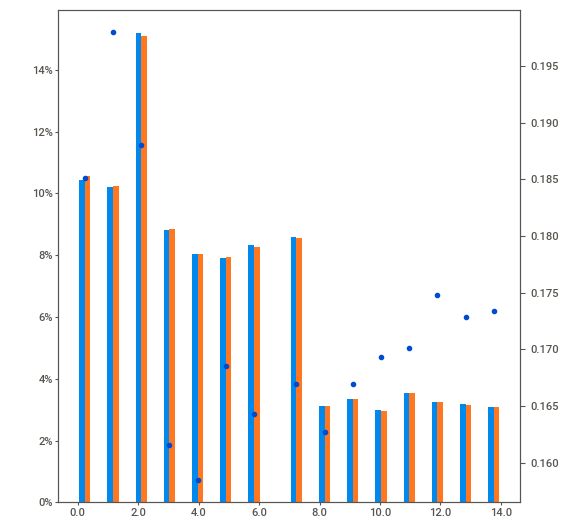
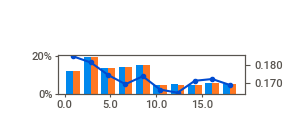
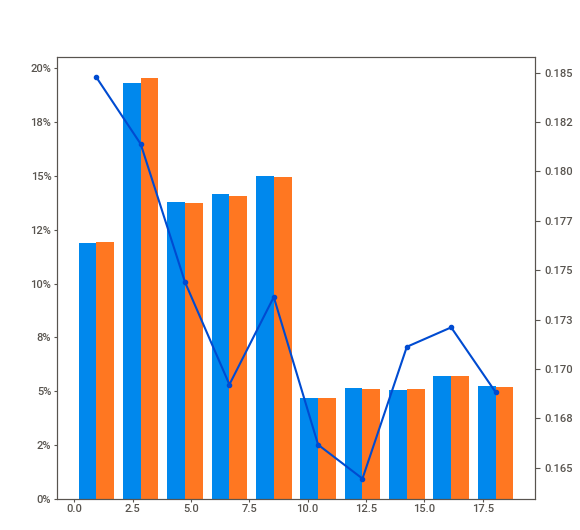
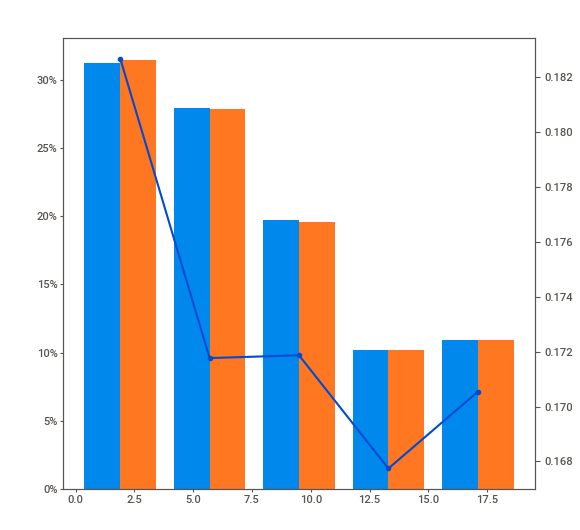
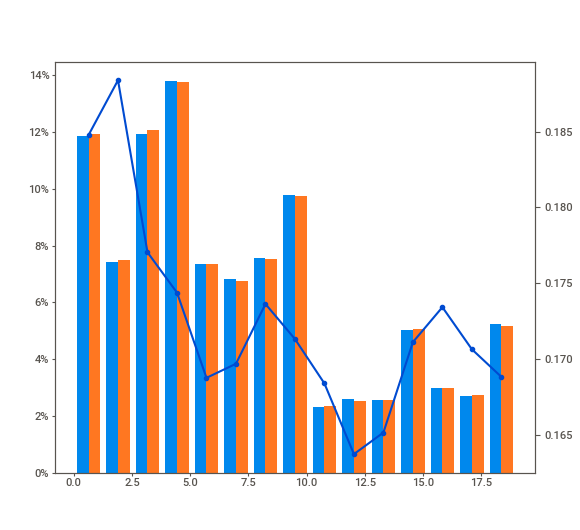
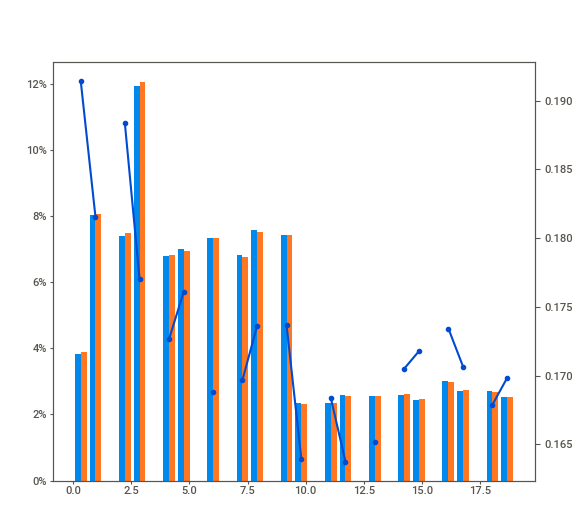
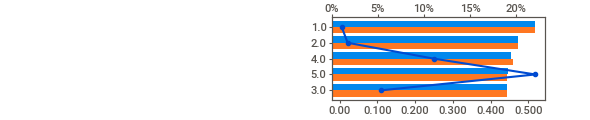
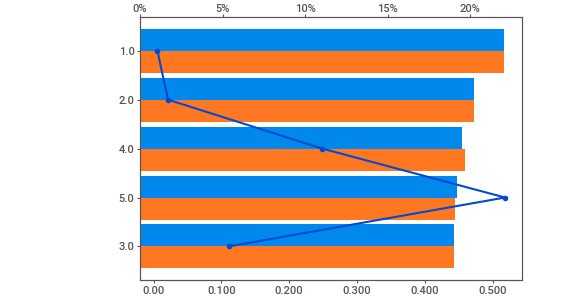
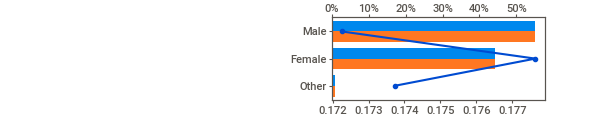
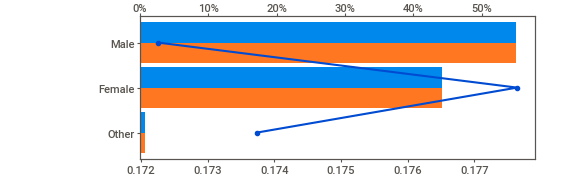
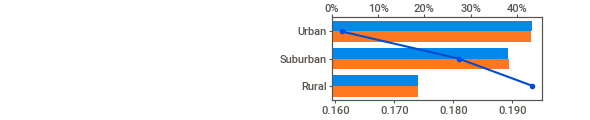
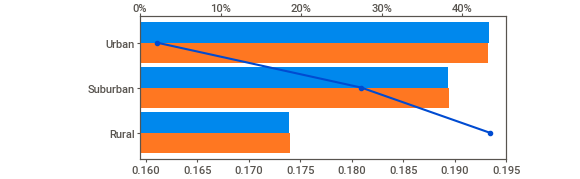
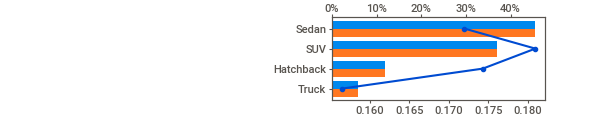
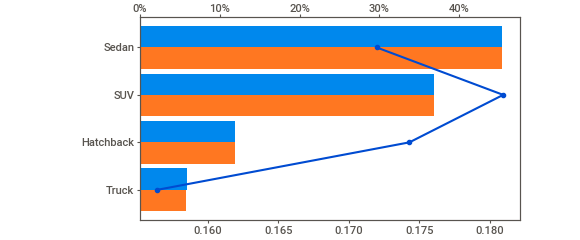
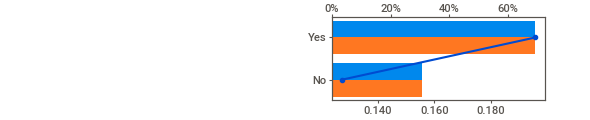
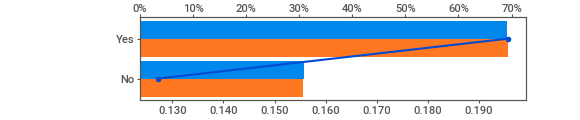
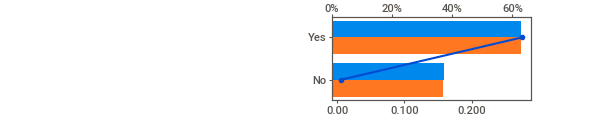
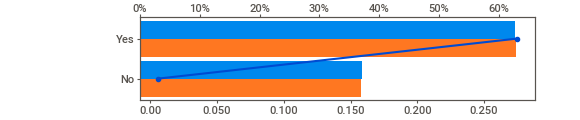
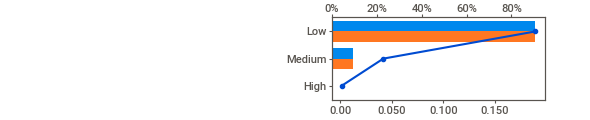
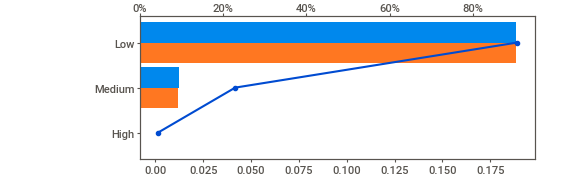
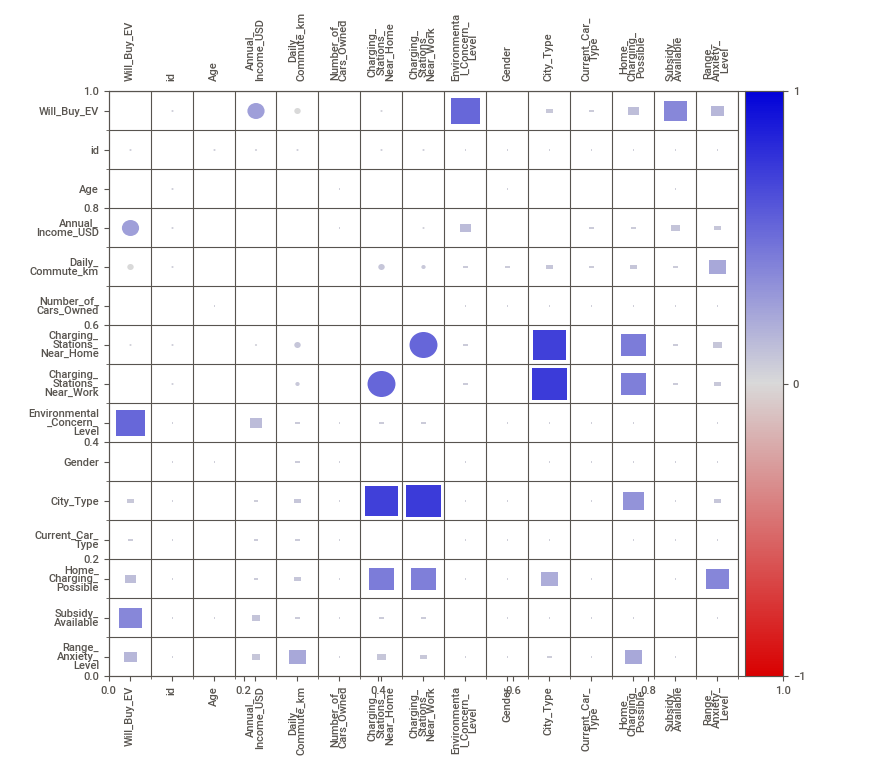
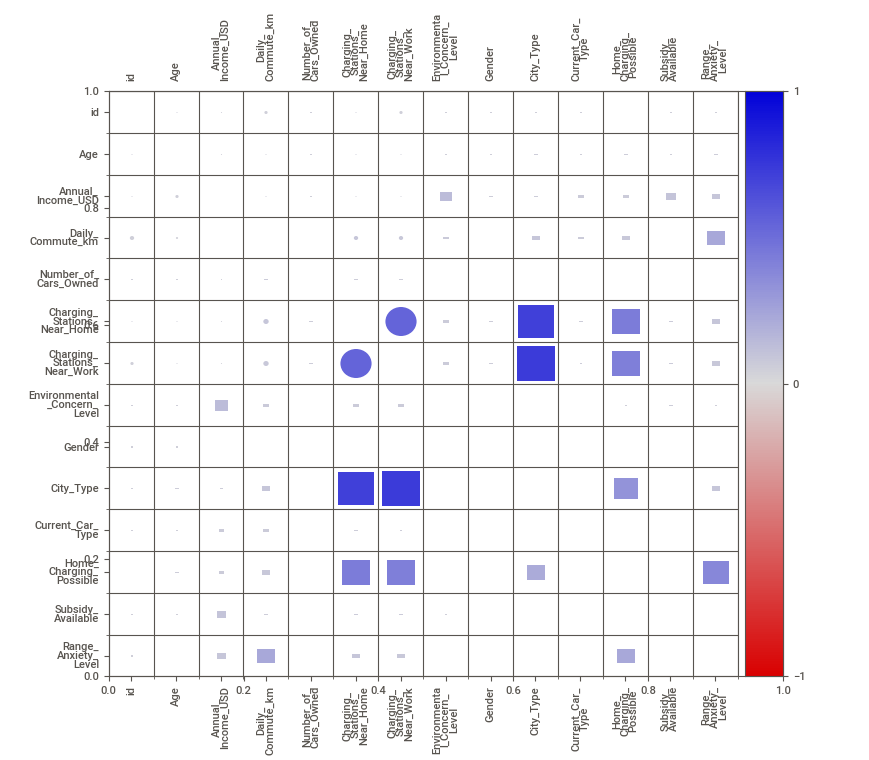

In [6]:
# Convert string target to numeric 0/1 for Sweetviz analysis
sweetviz_train_df = training_df.copy()
sweetviz_train_df[TARGET] = sweetviz_train_df[TARGET].map({'Yes': 1, 'No': 0})

feat_cfg = sv.FeatureConfig(force_num=[TARGET])

train_test_comparison_report = sv.compare(
    [sweetviz_train_df, "Training Data"],
    [test_df, "Test Data"],
    target_feat=TARGET,
    feat_cfg=feat_cfg
)

# Save HTML report file for full tab browsing
train_test_comparison_report.show_html(
    filepath="sweetviz_train_test.html",
    open_browser=False
)

# Render in notebook: expanded height, widescreen layout, scaled down to fit
train_test_comparison_report.show_notebook(
    w="100%",
    h=1000,
    scale=0.85
)

### Train vs Test Drift Analysis Insights

Based on Kolmogorov-Smirnov (KS) tests comparing numerical distributions between train (668,665 rows) and test (286,571 rows):
* **Zero Significant Drift**: All features exhibit virtually identical distributions (KS stats < 0.003, high p-values across `Age`, `Annual_Income_USD`, `Daily_Commute_km`, `Environmental_Concern_Level`, etc.).
* **Implication**: Test data is sampled from the exact same synthetic population. Local 5-fold cross-validation will closely match public and private leaderboard performance.

### Standalone Training Profile Report

*(Saved locally as [sweetviz_training_profile.html](sweetviz_training_profile.html))*

                                             |                                                                …

Report sweetviz_training_profile.html was generated.



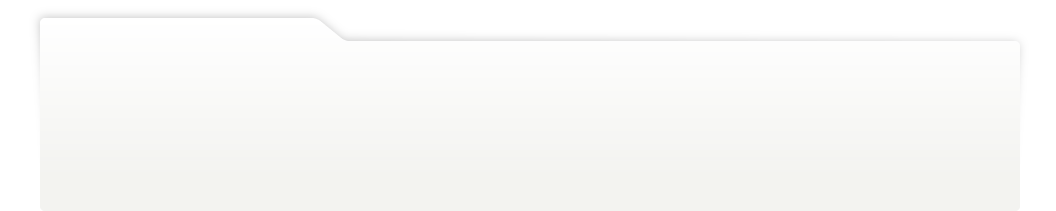
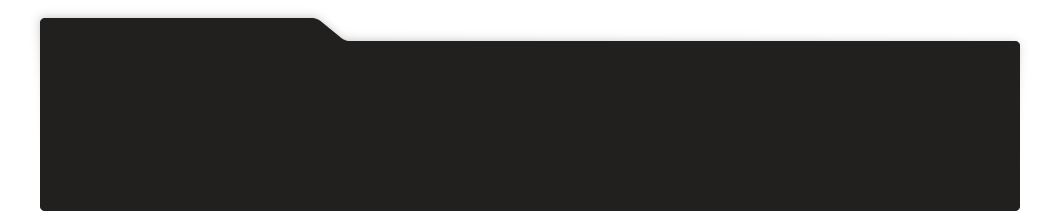
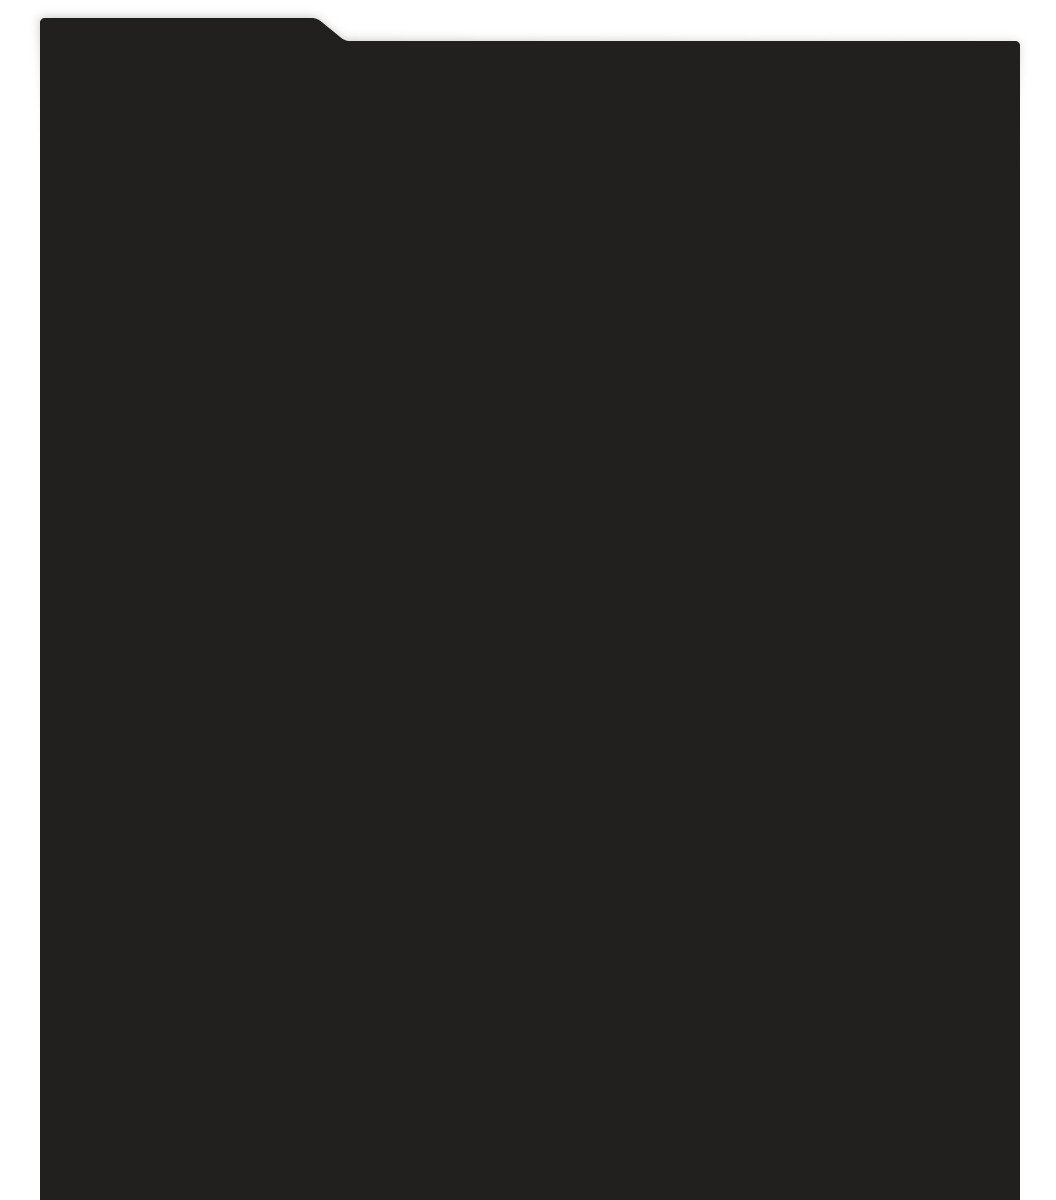
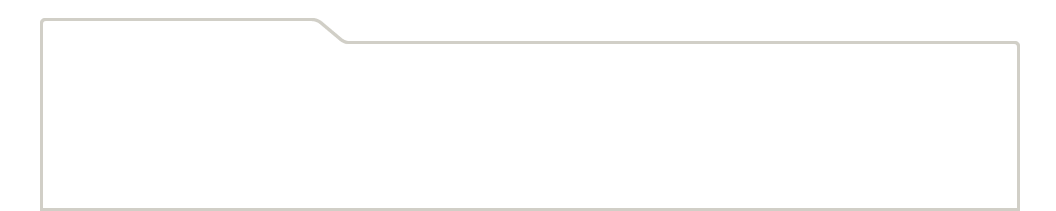
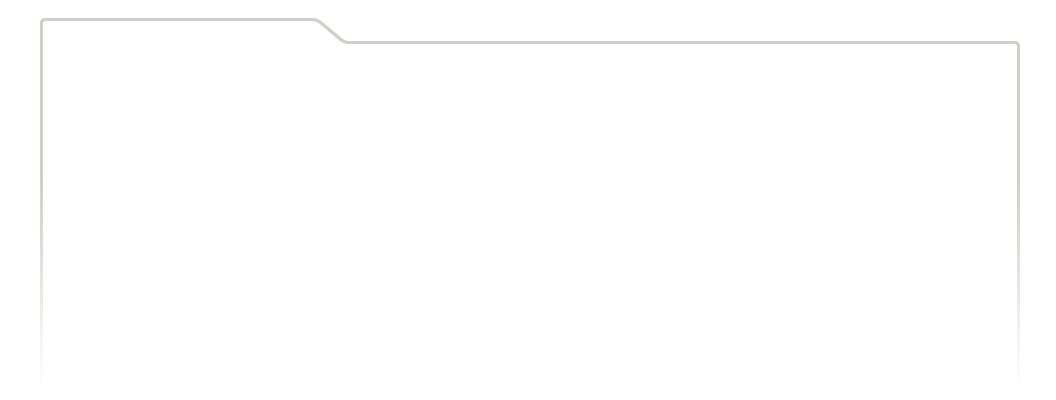
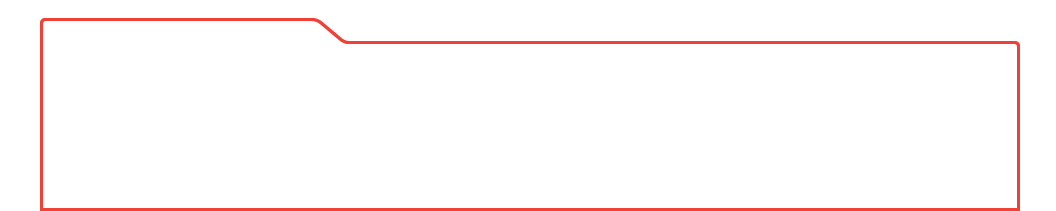
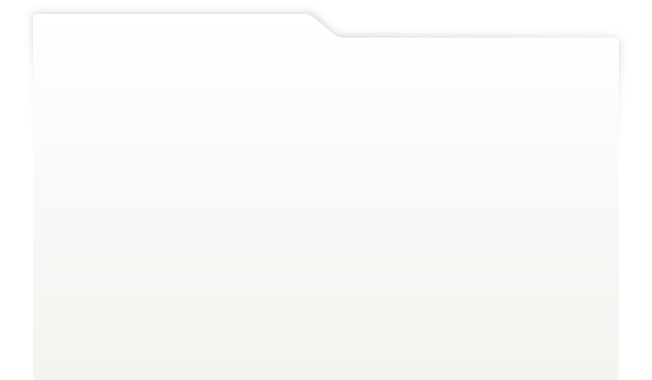
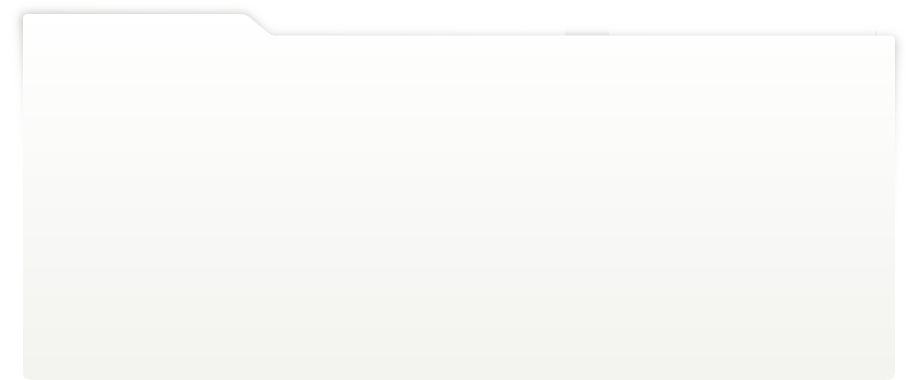
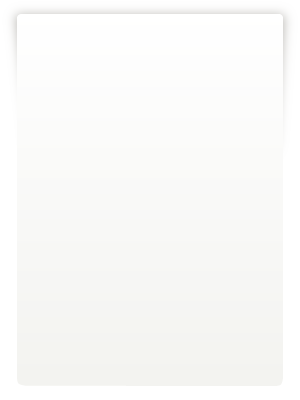
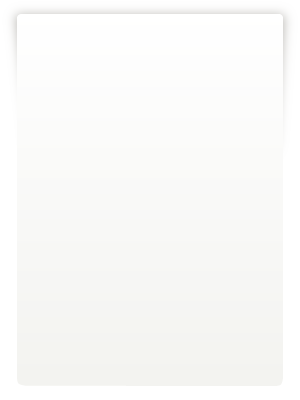
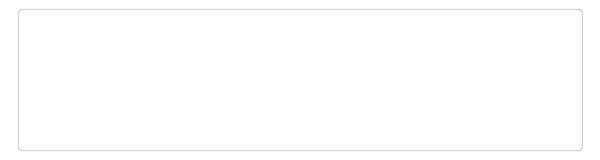
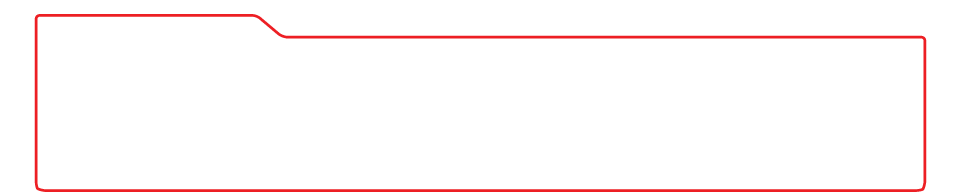
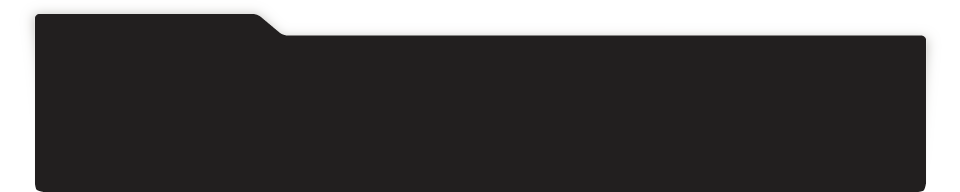
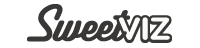
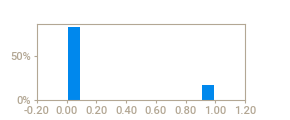
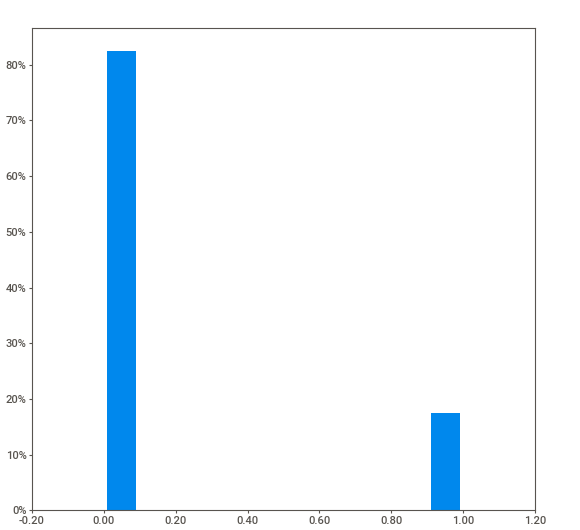
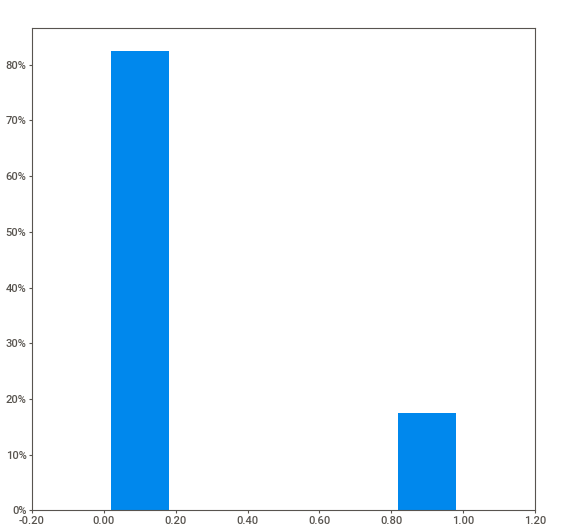
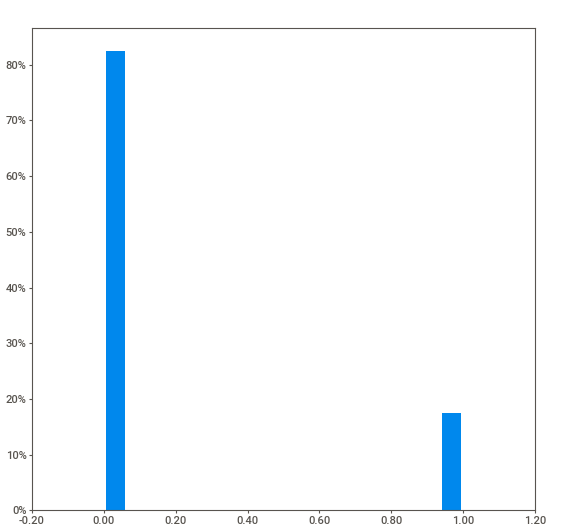
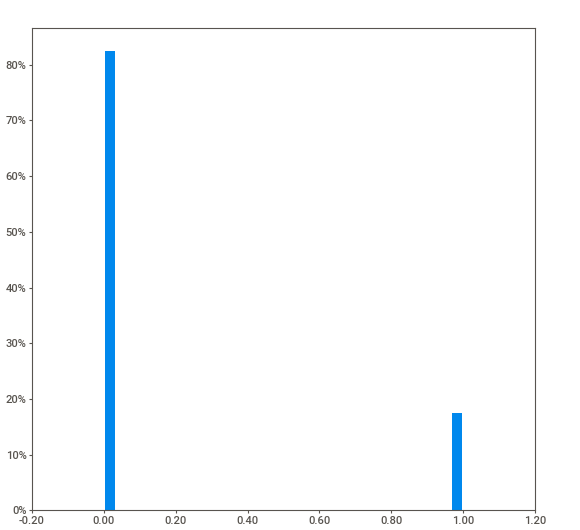
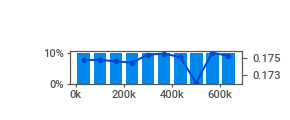
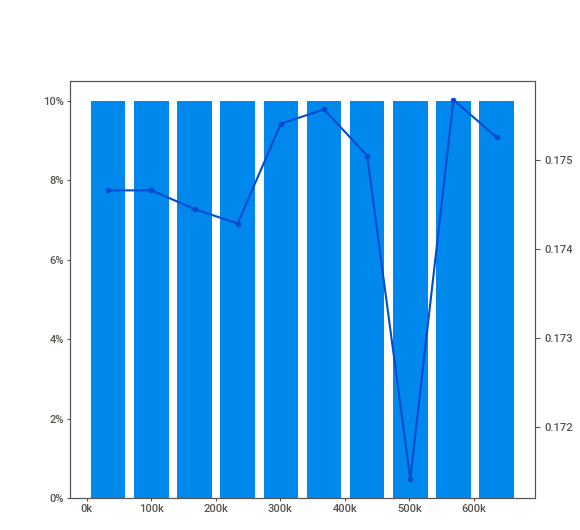
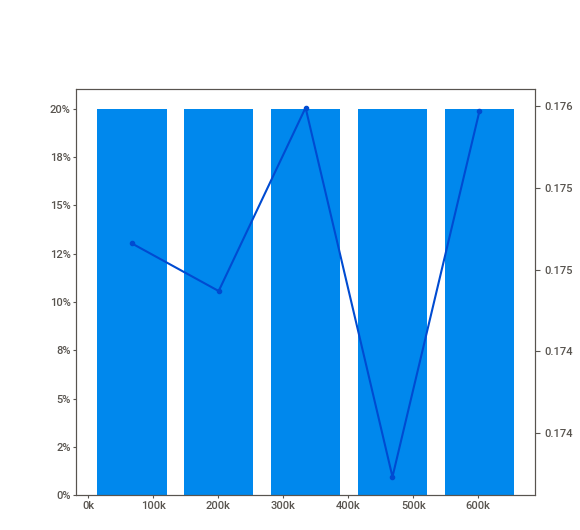
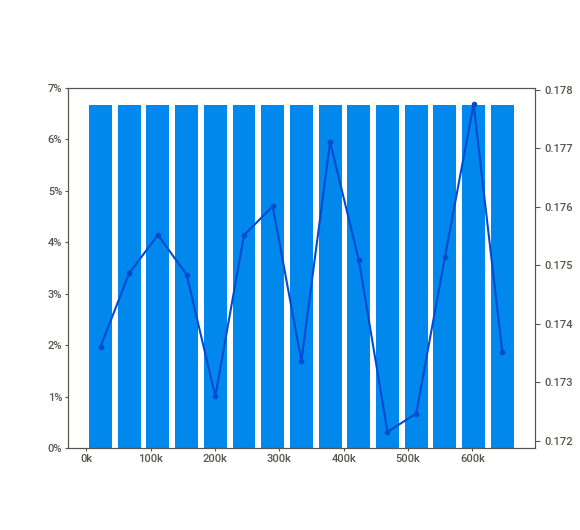
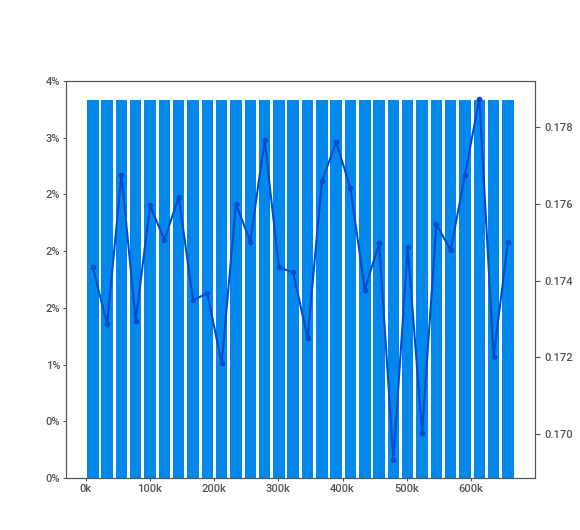
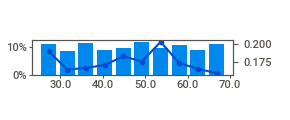
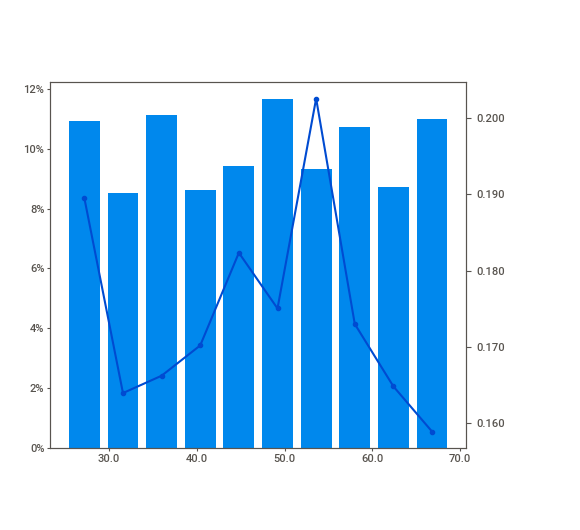
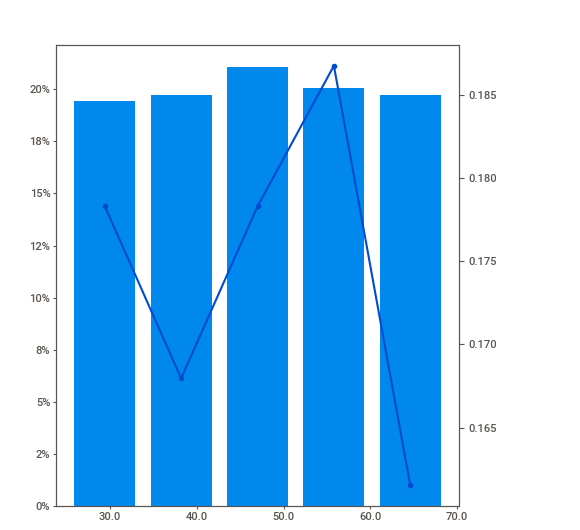
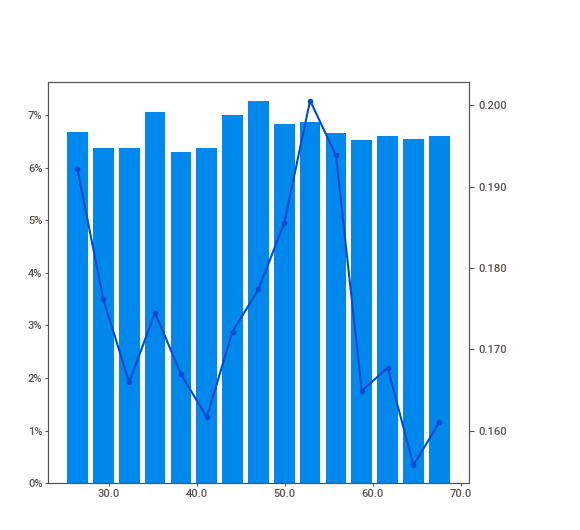
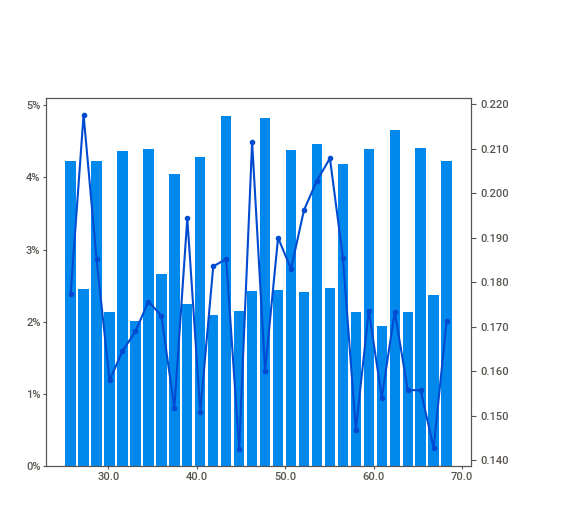
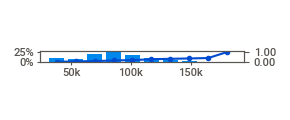
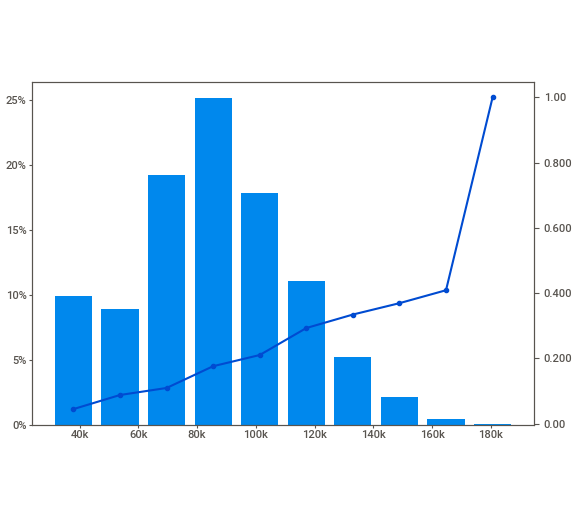
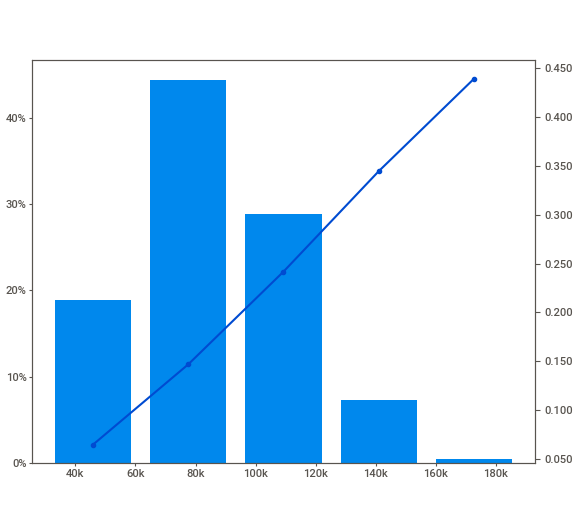
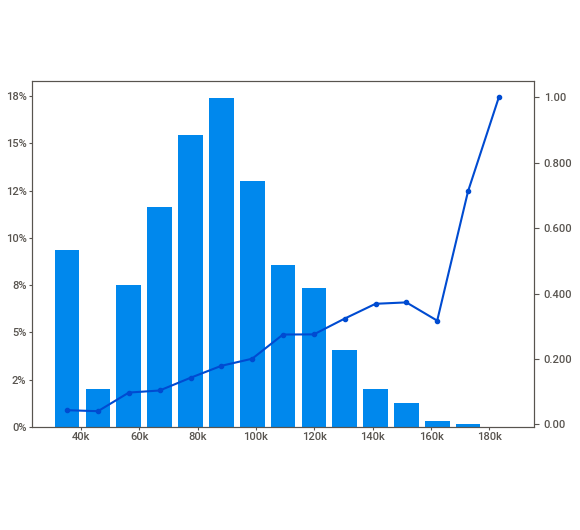
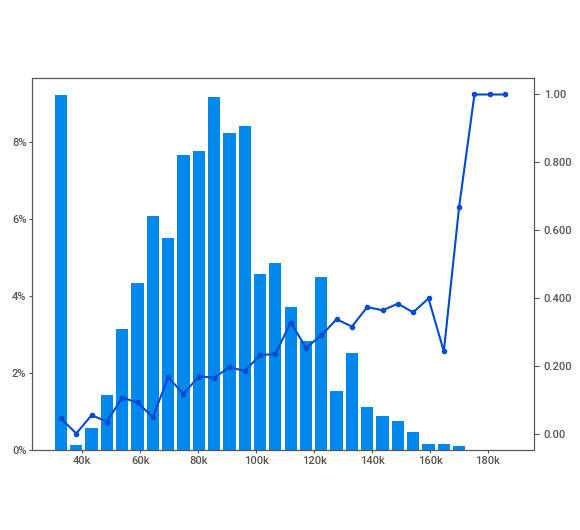
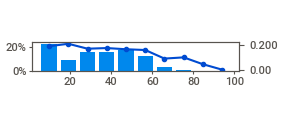
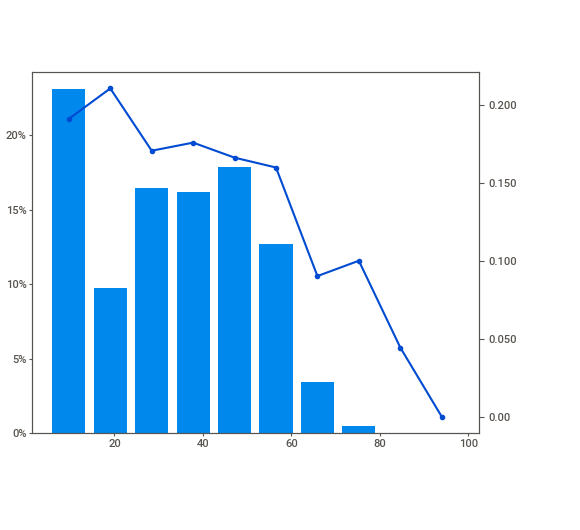
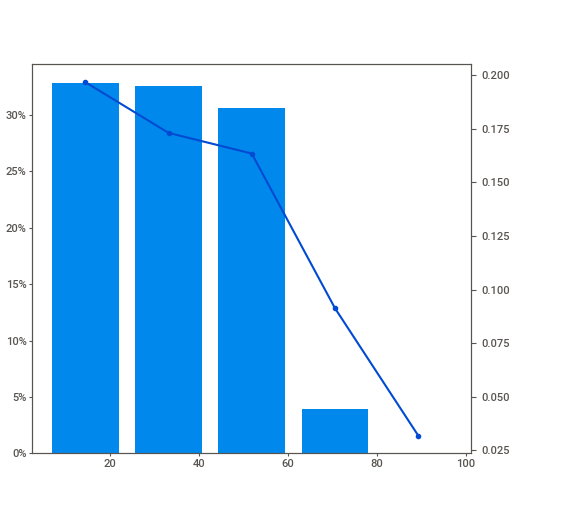
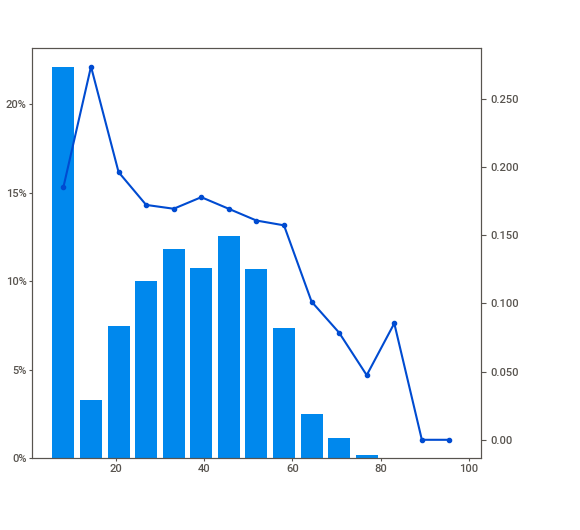
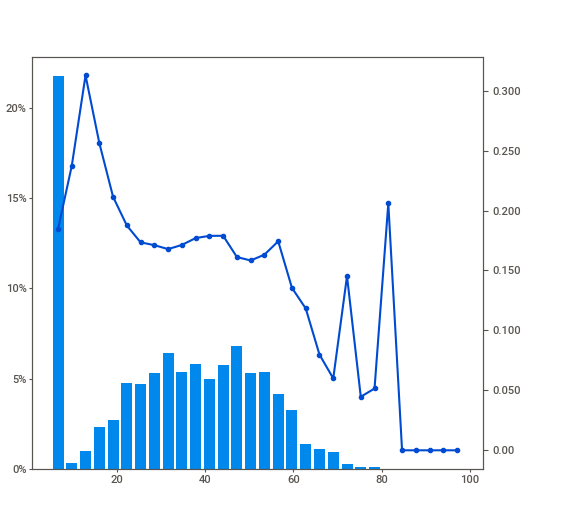
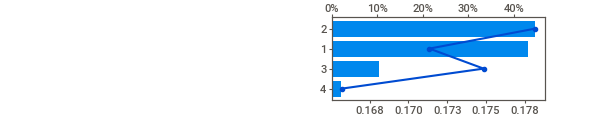
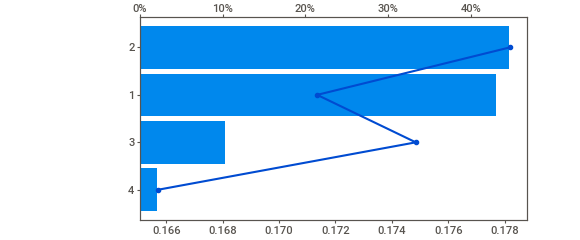
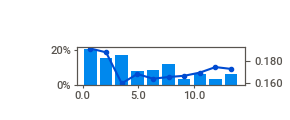
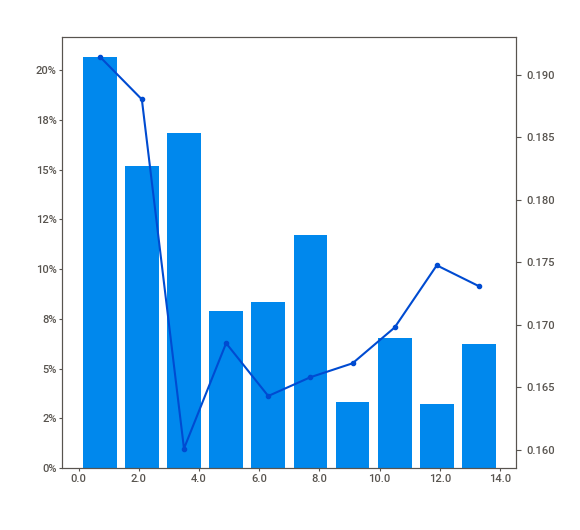
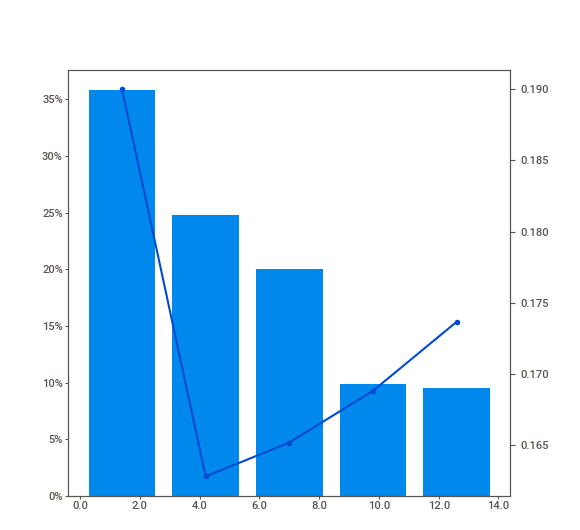
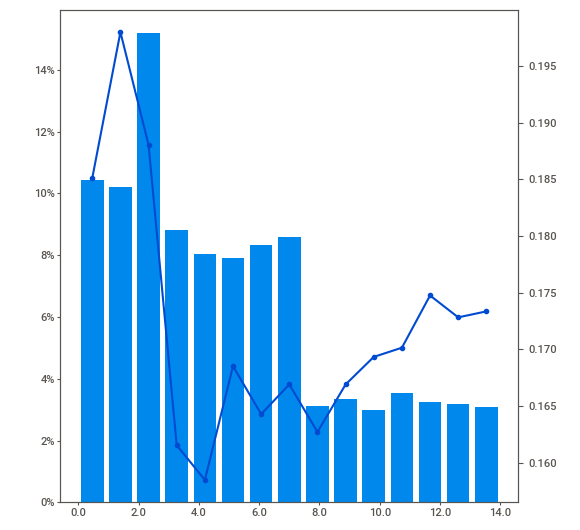
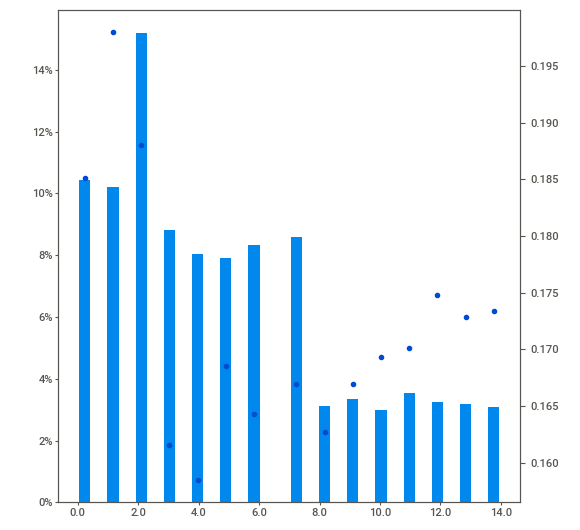
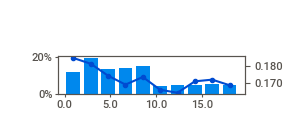
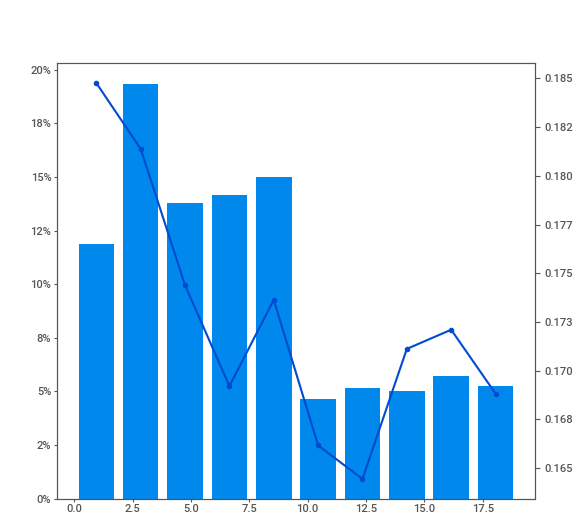
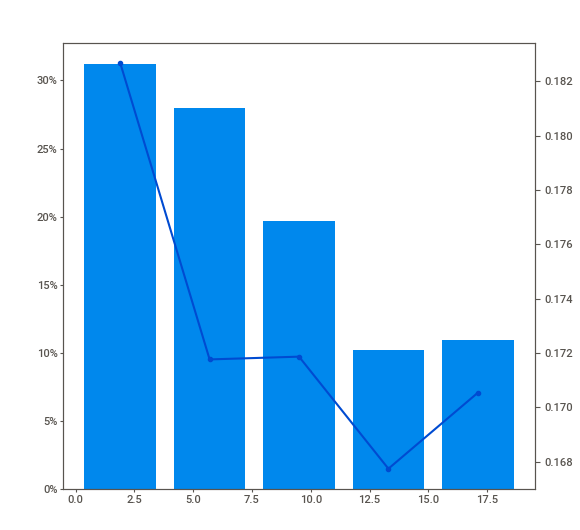
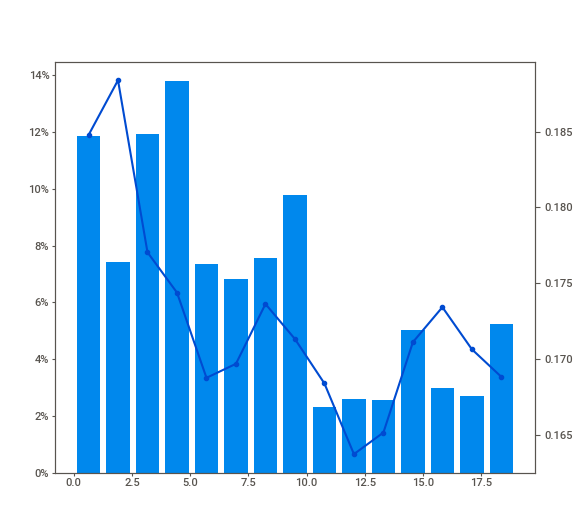
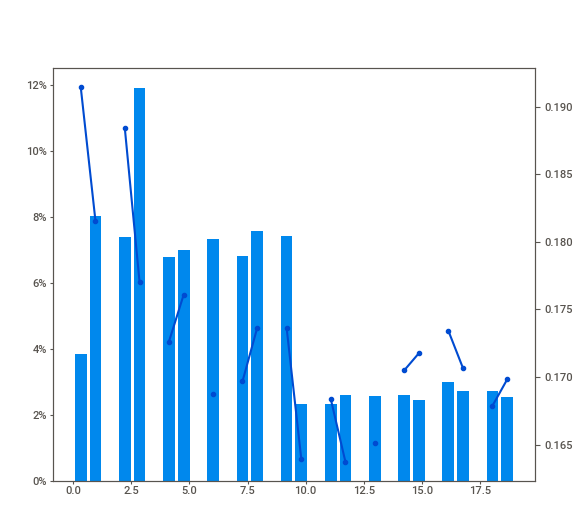
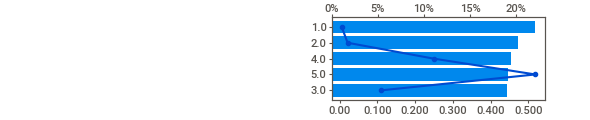
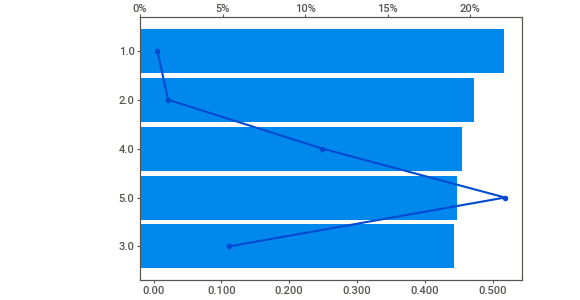
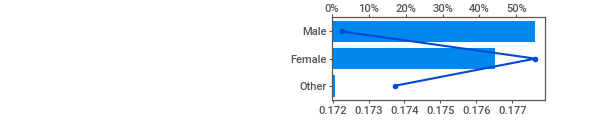
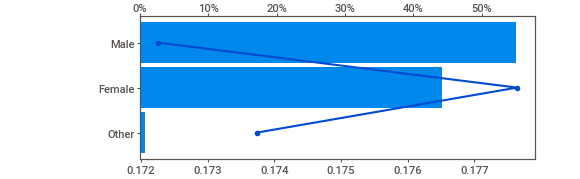
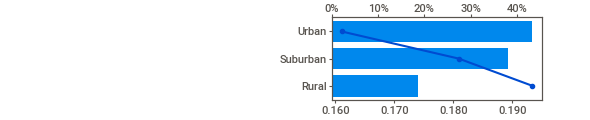
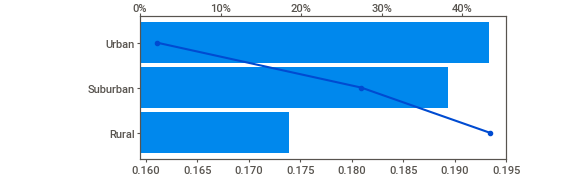
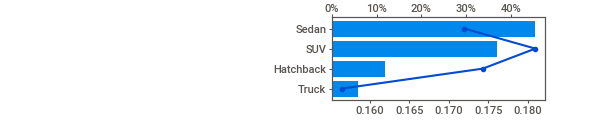
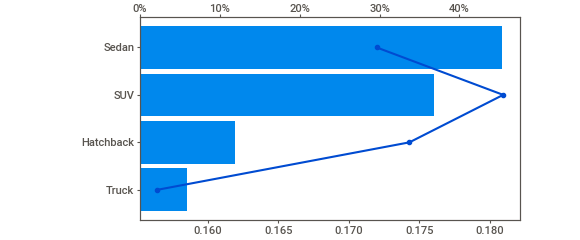
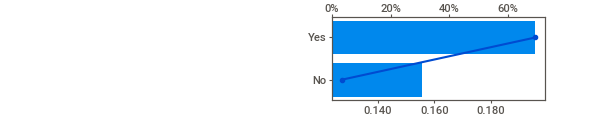
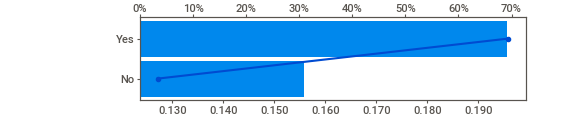
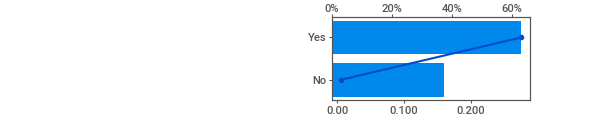
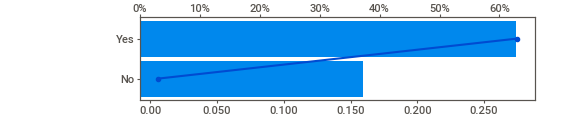
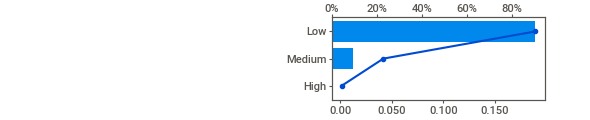
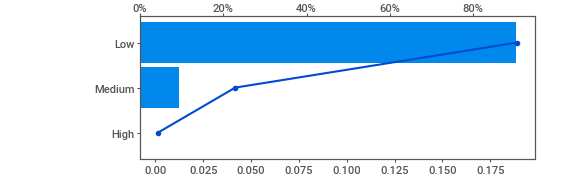
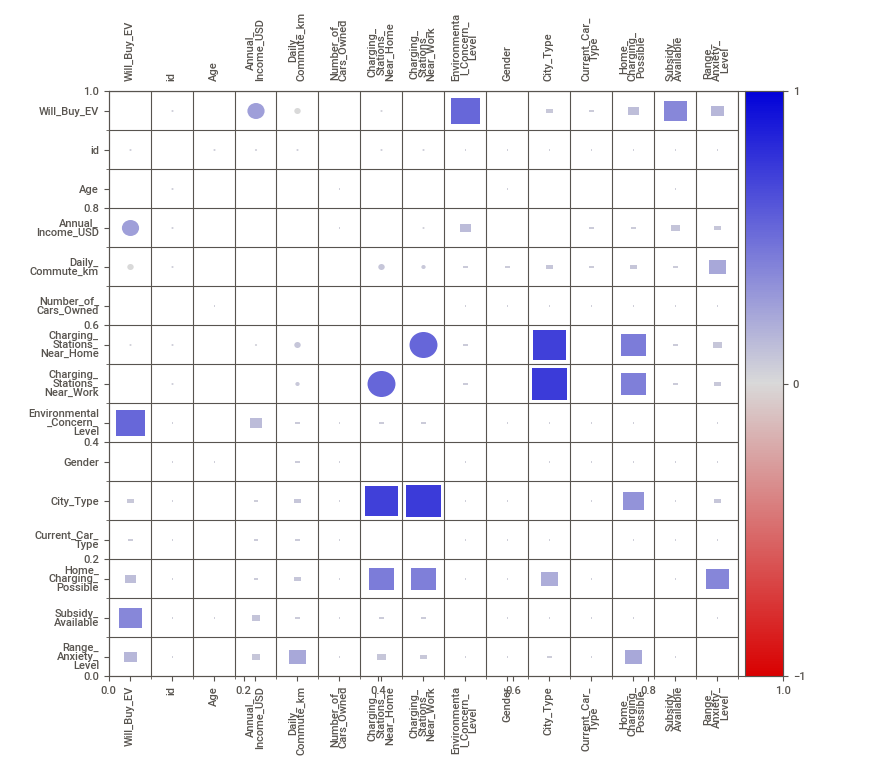
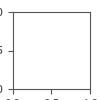

In [7]:
training_report = sv.analyze(
    [sweetviz_train_df, "Training Data"],
    target_feat=TARGET,
    feat_cfg=feat_cfg
)

# Save HTML report file
training_report.show_html(
    filepath="sweetviz_training_profile.html",
    open_browser=False
)

# Render in notebook
training_report.show_notebook(
    w="100%",
    h=1000,
    scale=0.85
)

### Intra-class Comparison (Will Buy EV vs. Will Not Buy EV)

Compare buyers (`Will_Buy_EV == 'Yes'`) versus non-buyers (`Will_Buy_EV == 'No'`).

                                             |                                                                …

Report sweetviz_ev_buyers_intra.html was generated.



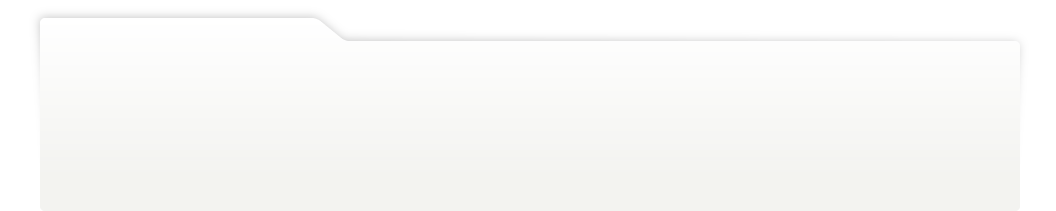
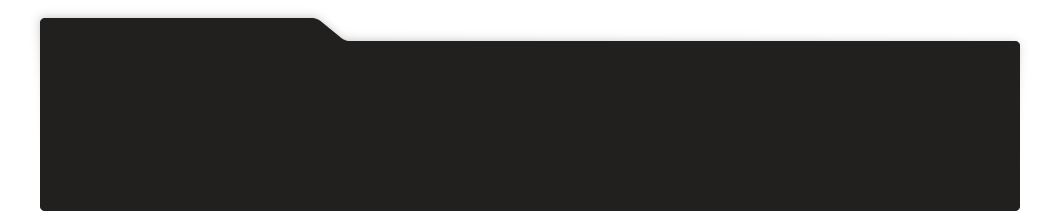
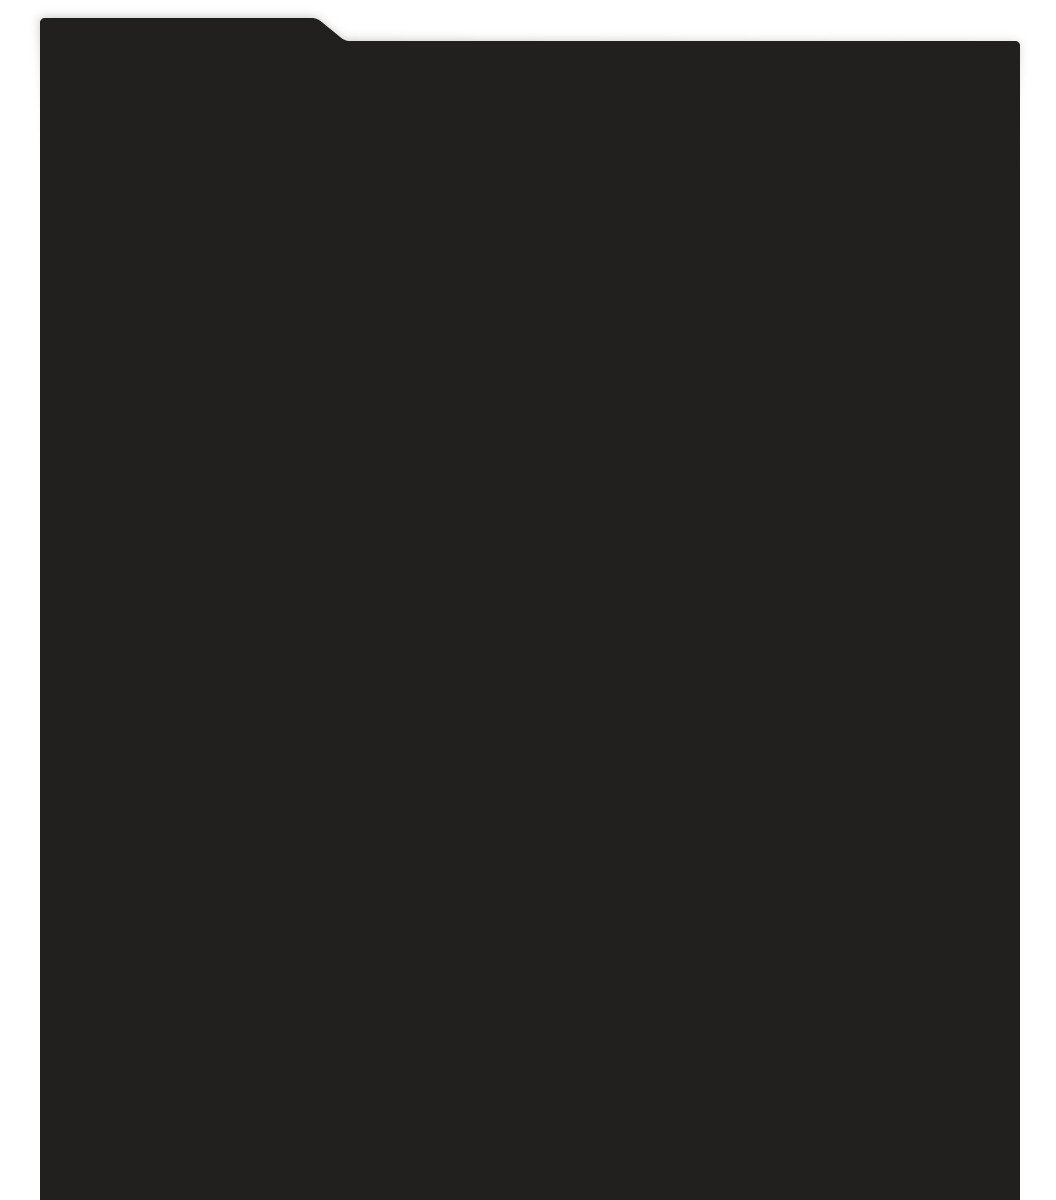
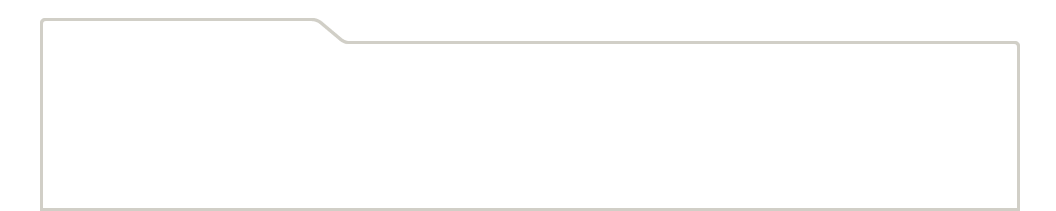
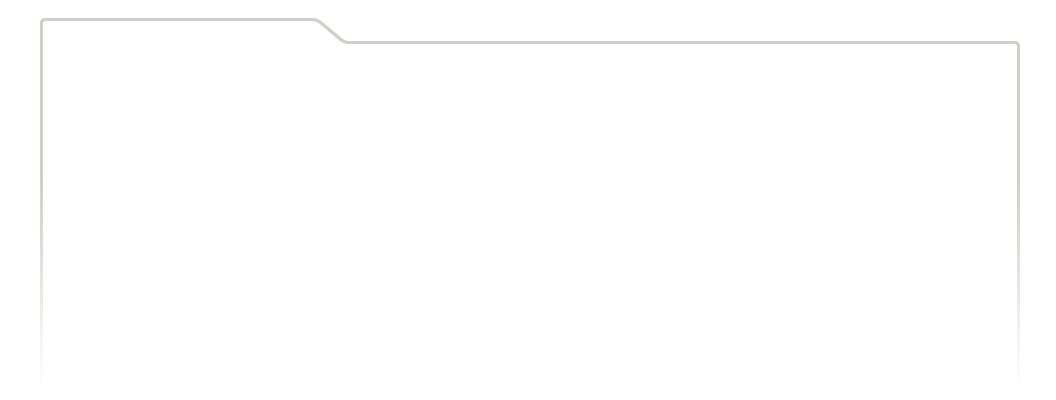
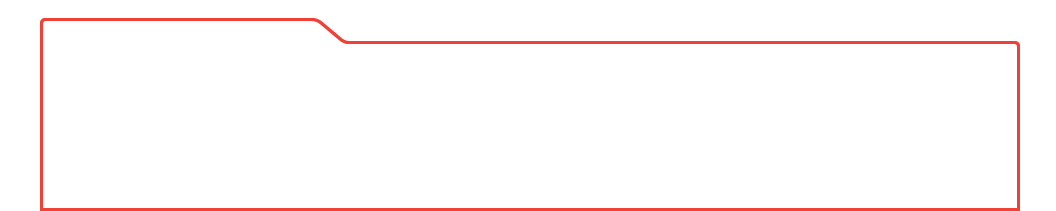
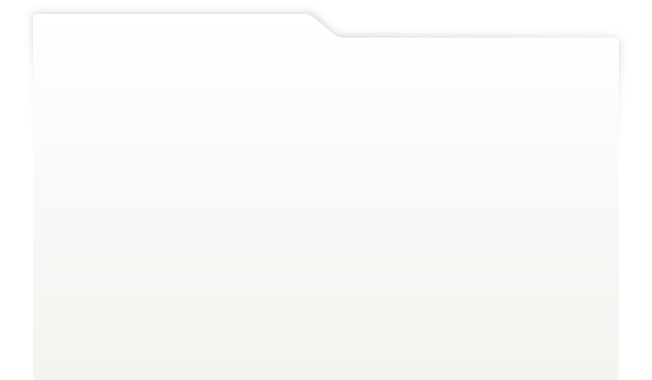
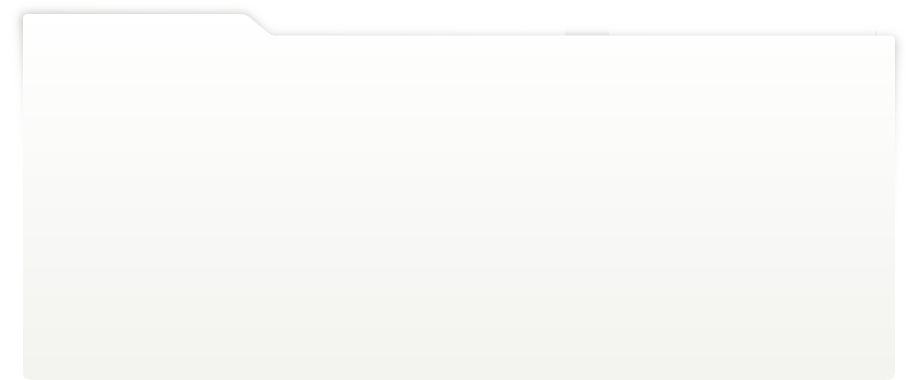
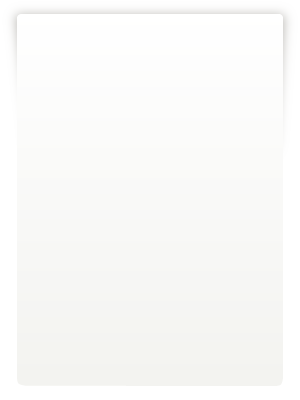
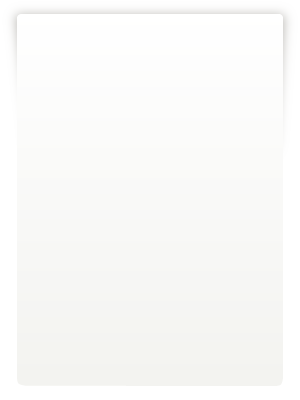
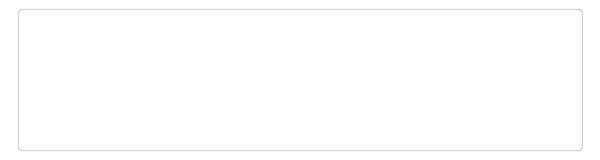
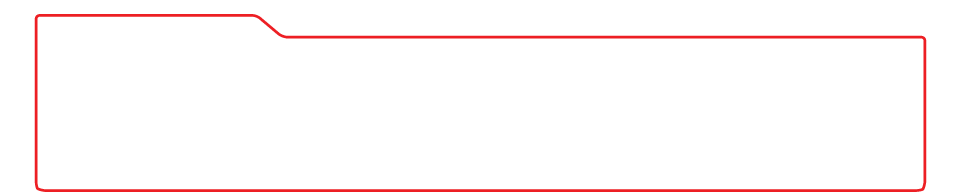
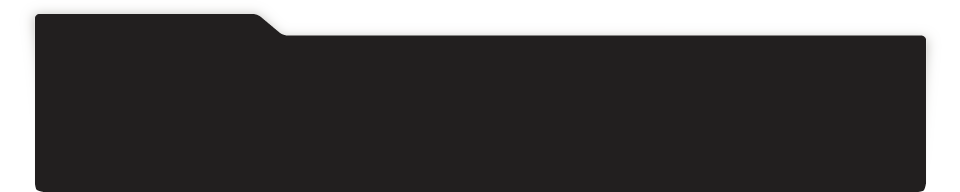
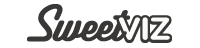
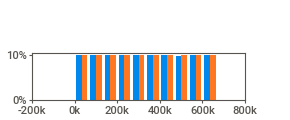
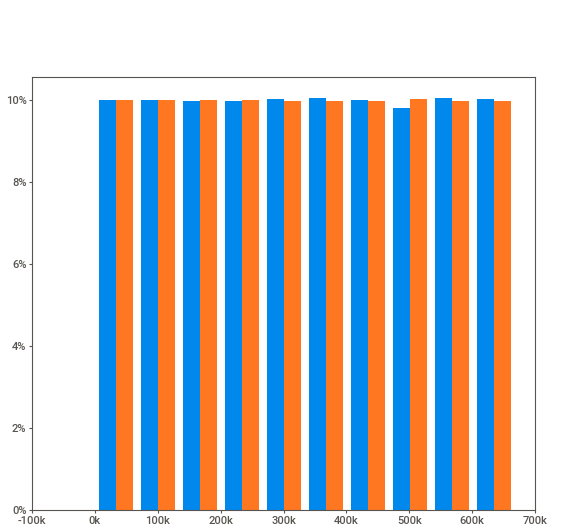
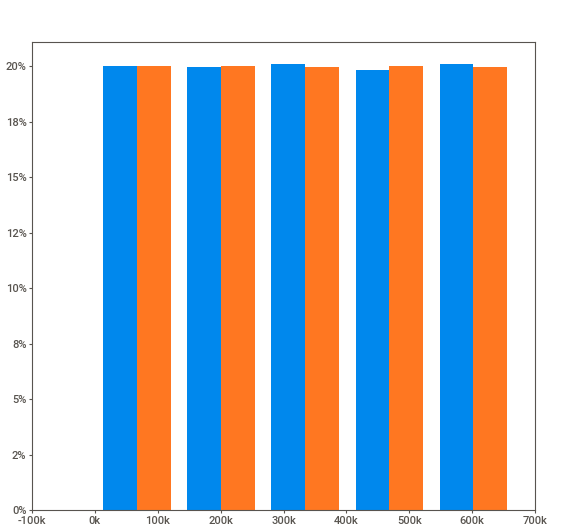
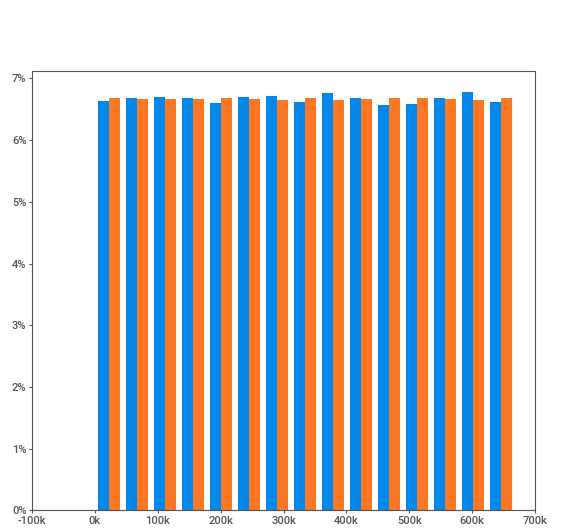
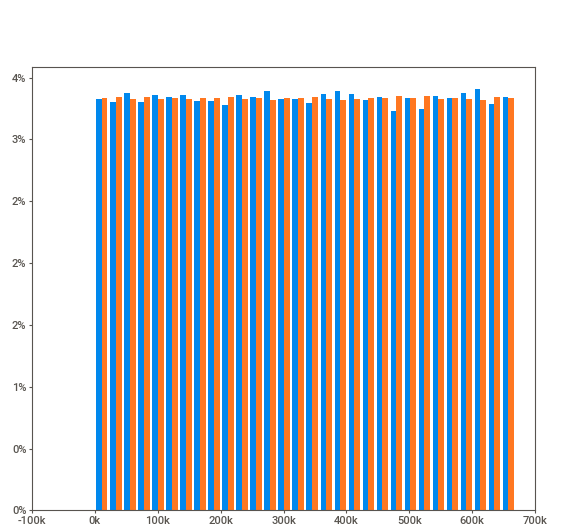
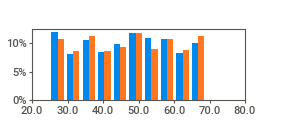
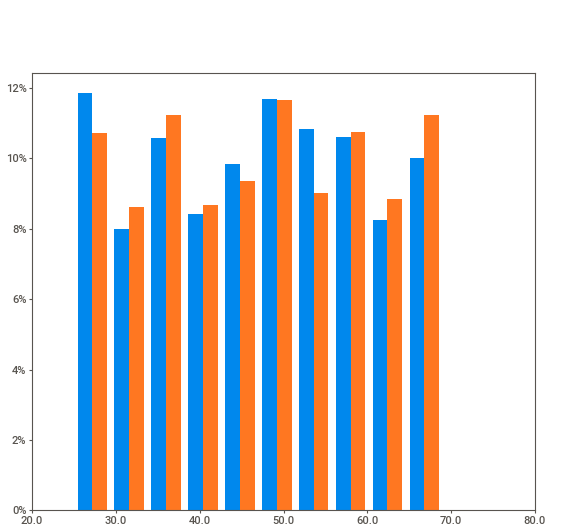
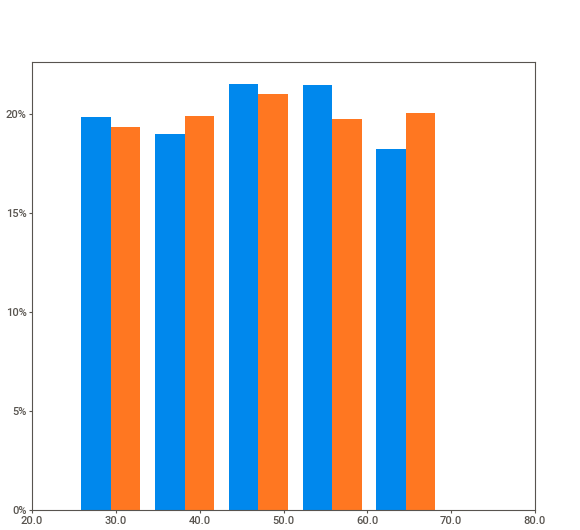
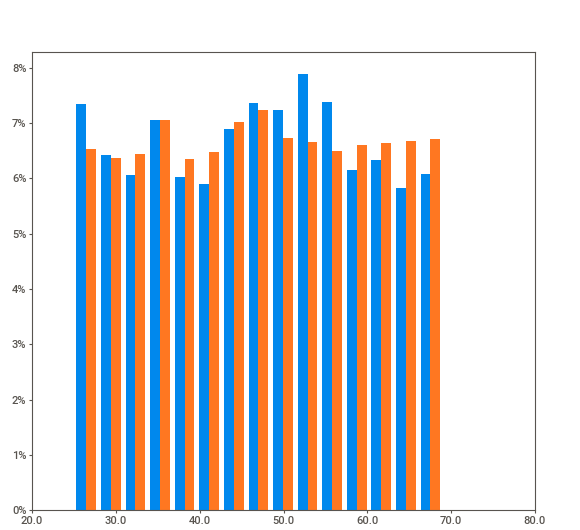
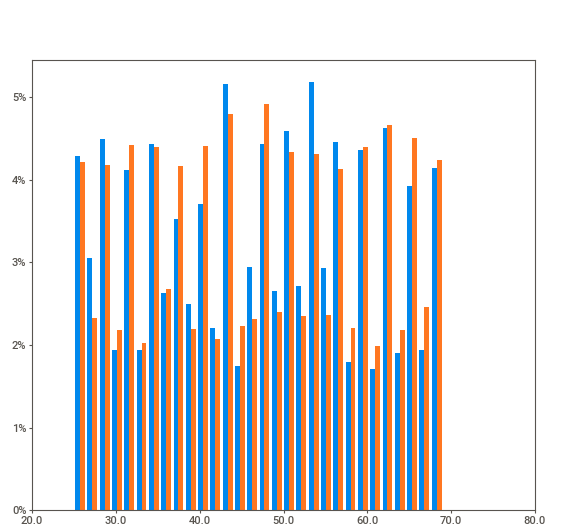
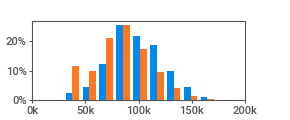
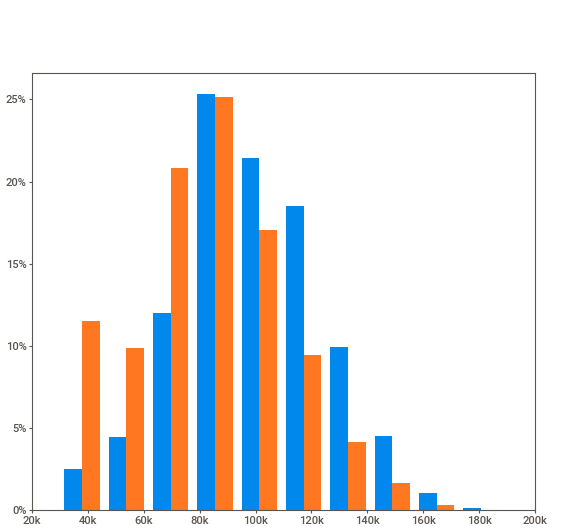
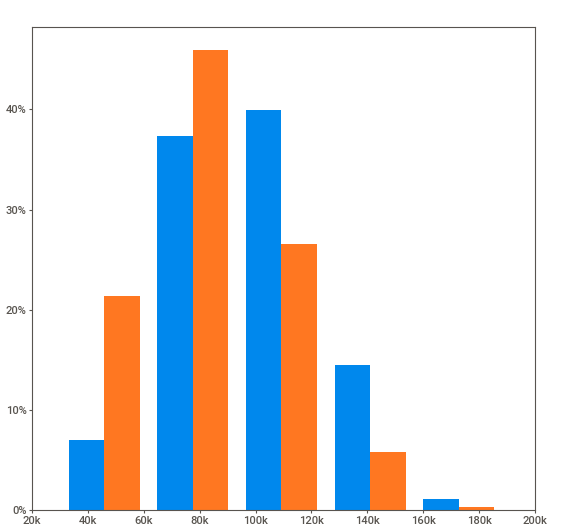
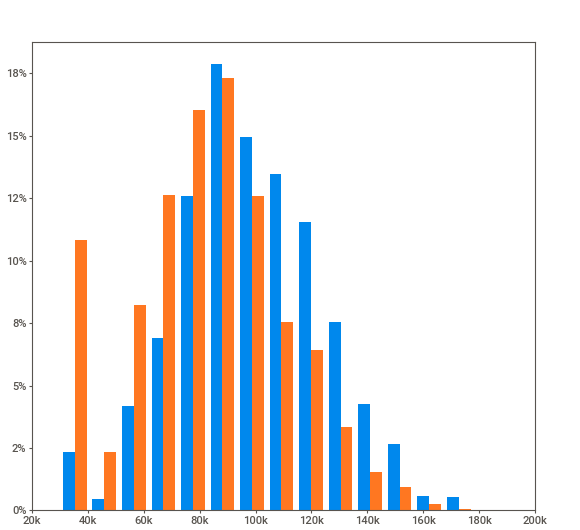
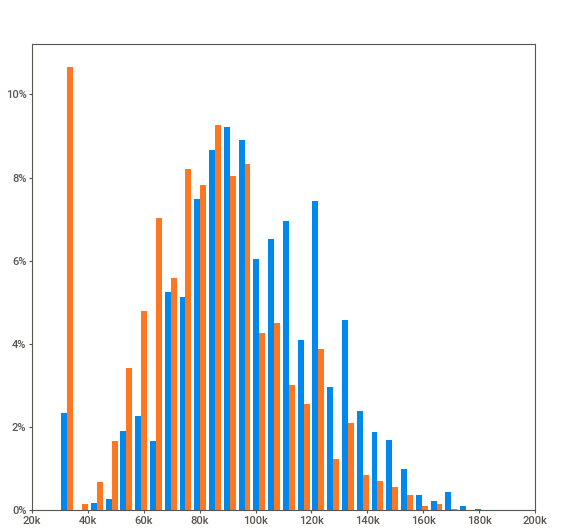
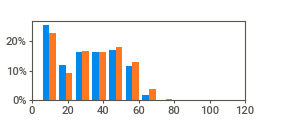
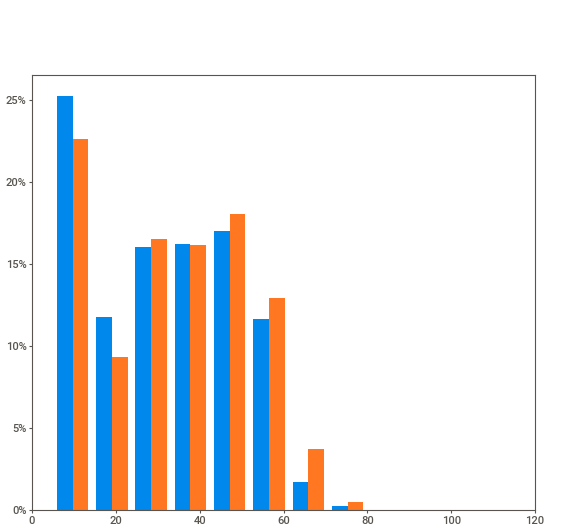
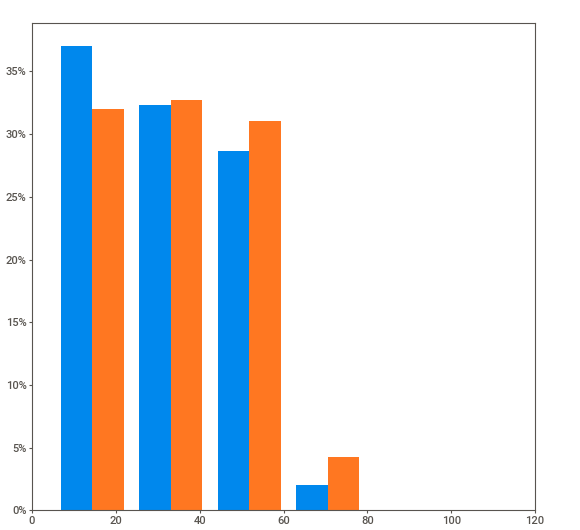
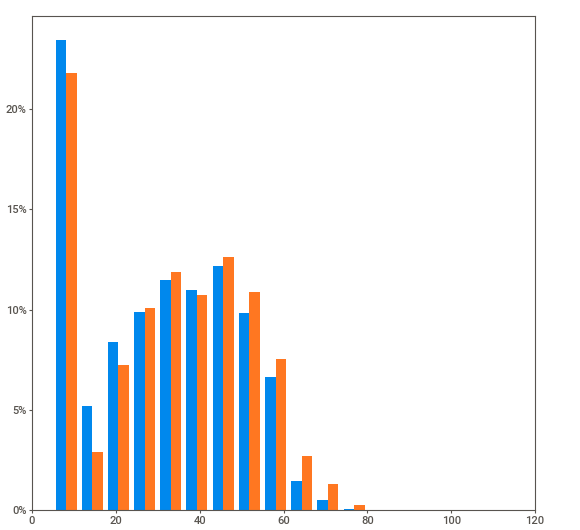
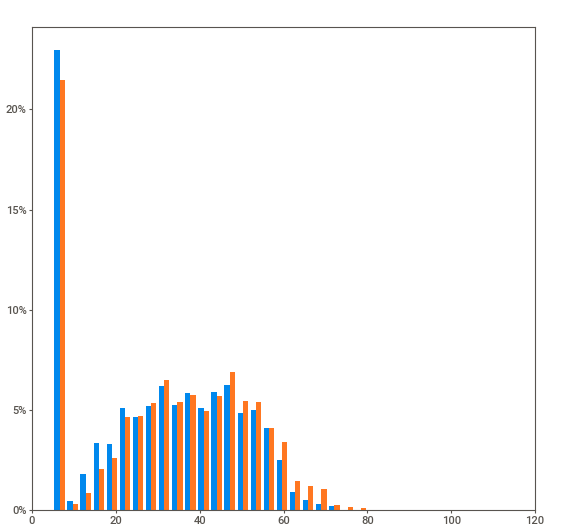
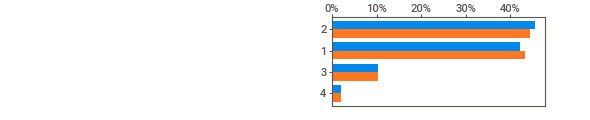
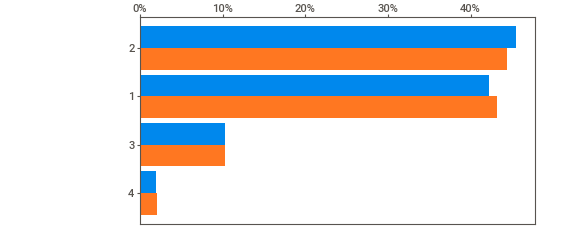
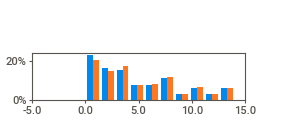
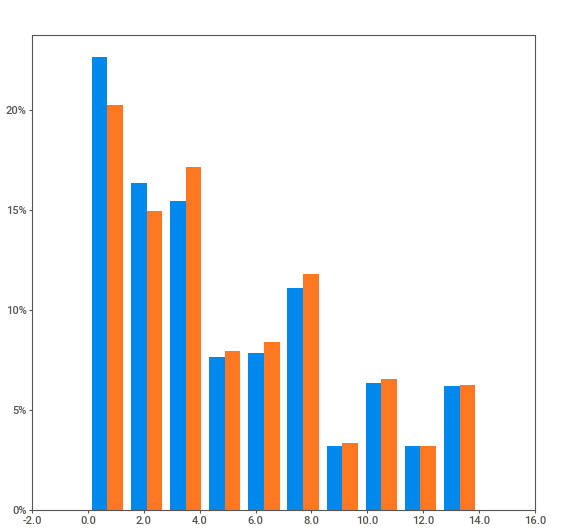
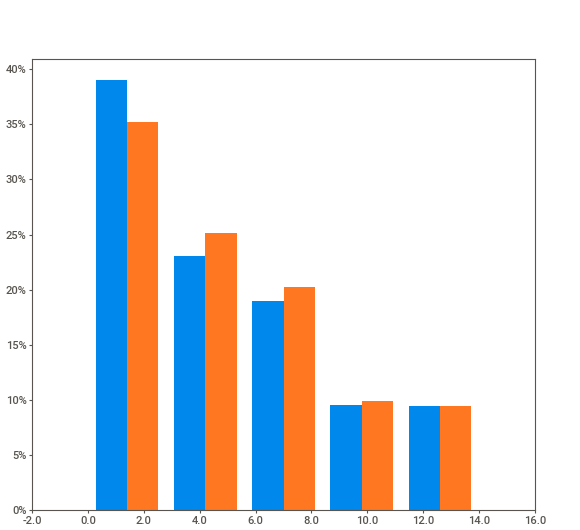
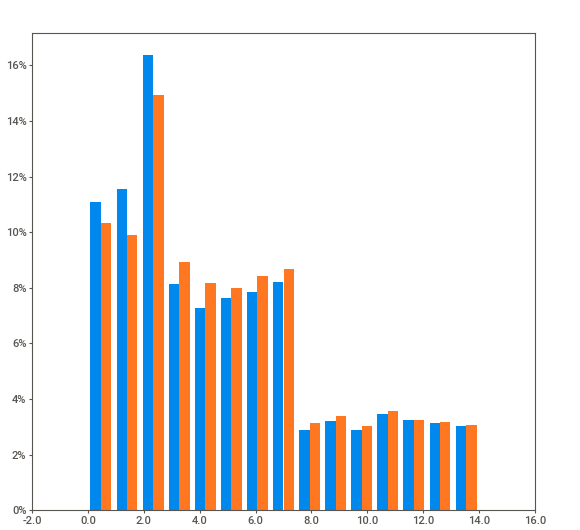
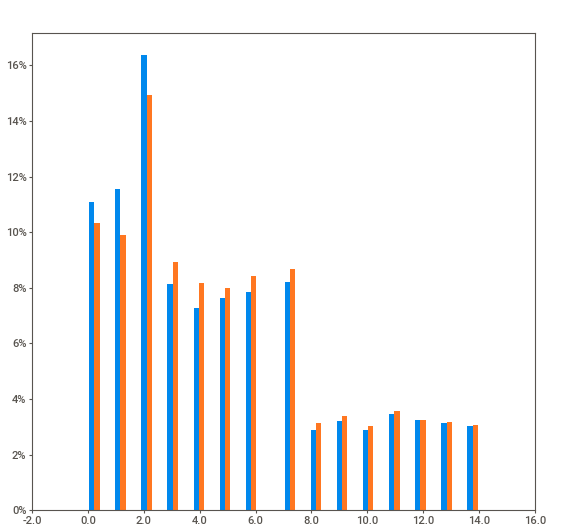
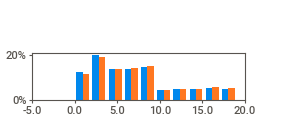
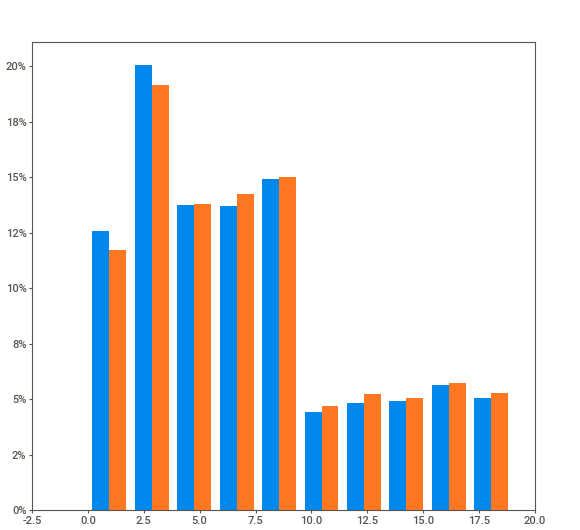
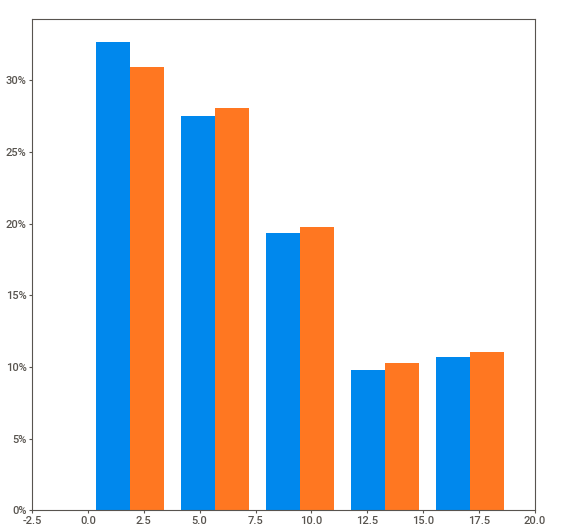
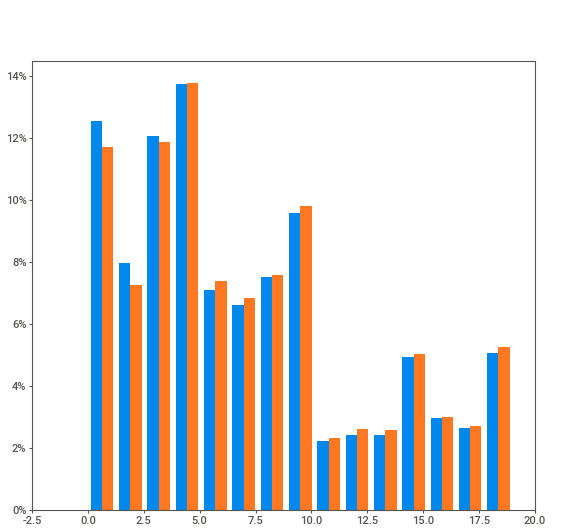
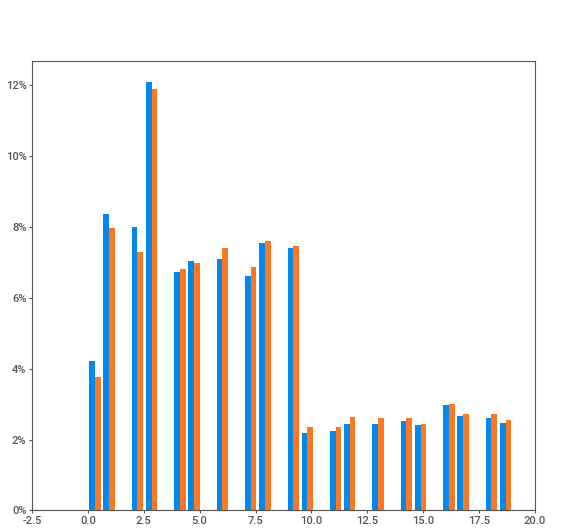
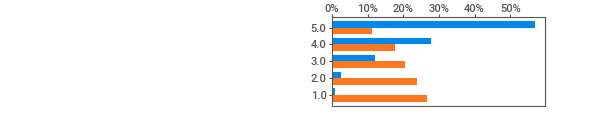
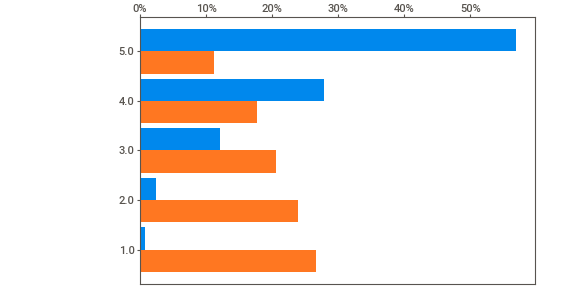
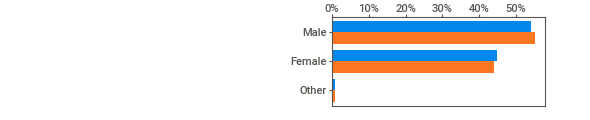
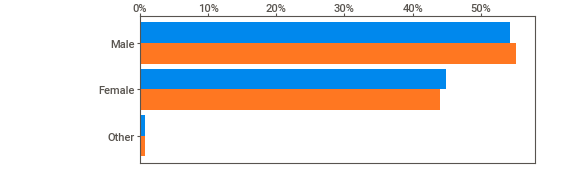
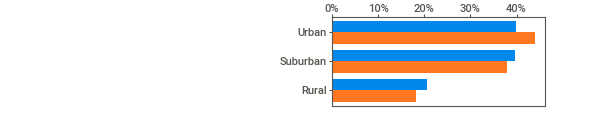
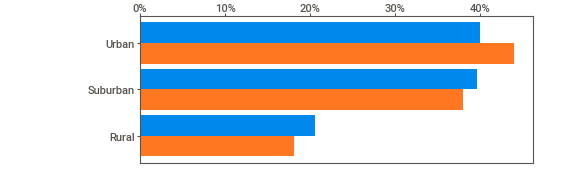
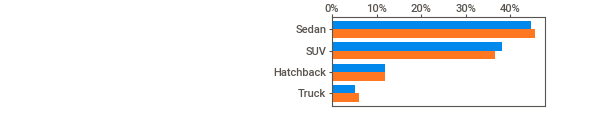
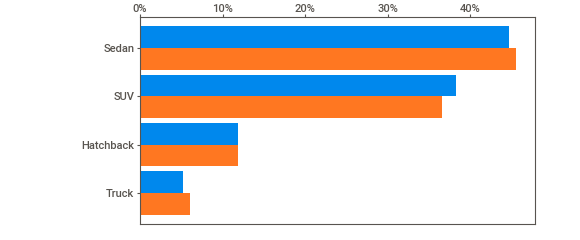
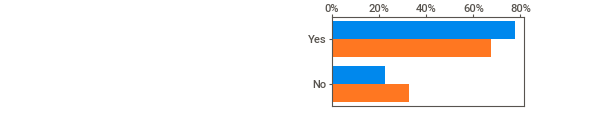
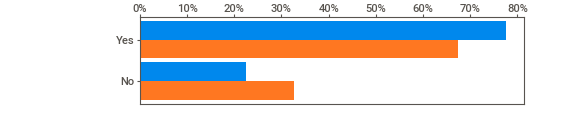
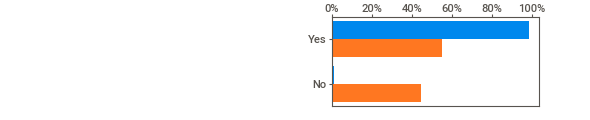
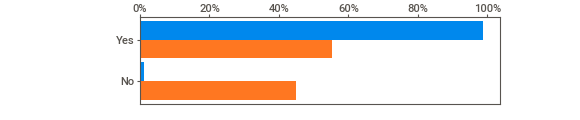
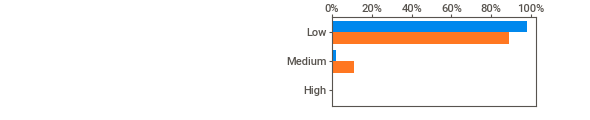
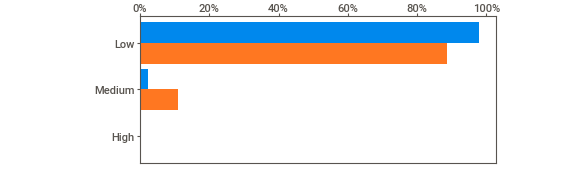
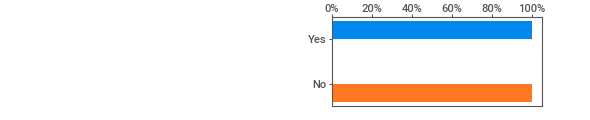
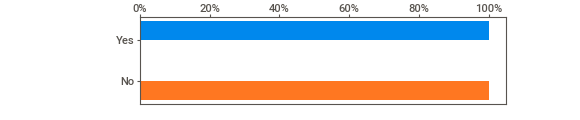
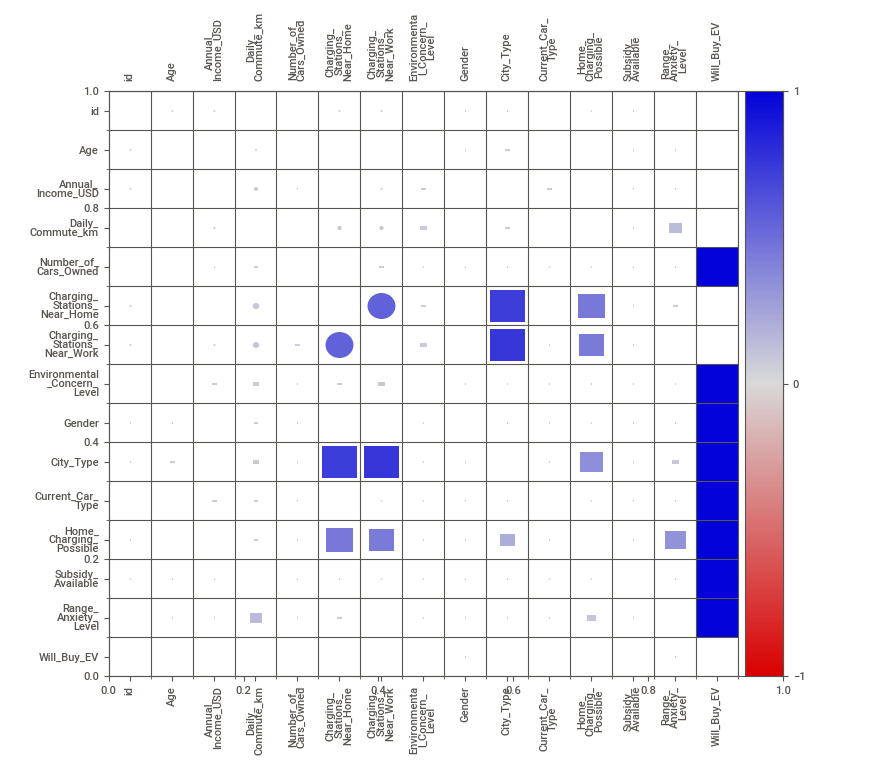
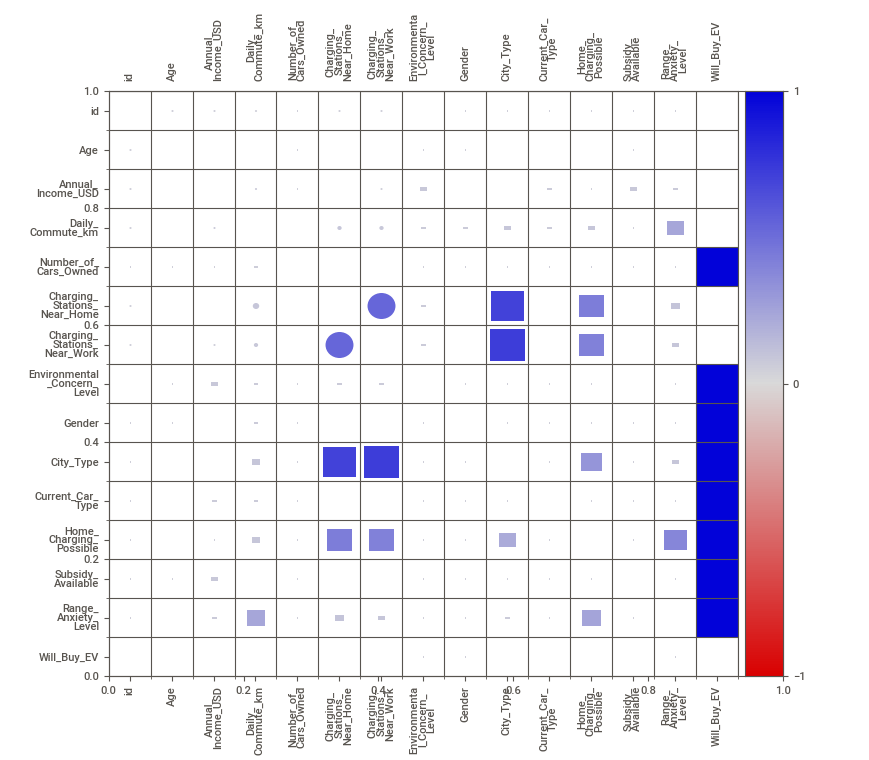

In [8]:
ev_buyers_vs_others_report = sv.compare_intra(
    training_df,
    training_df[TARGET] == 'Yes',
    ["Will Buy EV", "Will Not Buy EV"],
    target_feat=None
)

# Save HTML report file
ev_buyers_vs_others_report.show_html(
    filepath="sweetviz_ev_buyers_intra.html",
    open_browser=False
)

# Render in notebook
ev_buyers_vs_others_report.show_notebook(
    w="100%",
    h=1000,
    scale=0.85
)

## 4. Custom Visualizations (DataVisualizer)

Run our target-aware visualization suite to extract top signals, target trends, and categorical relationships.

Using XKCD style


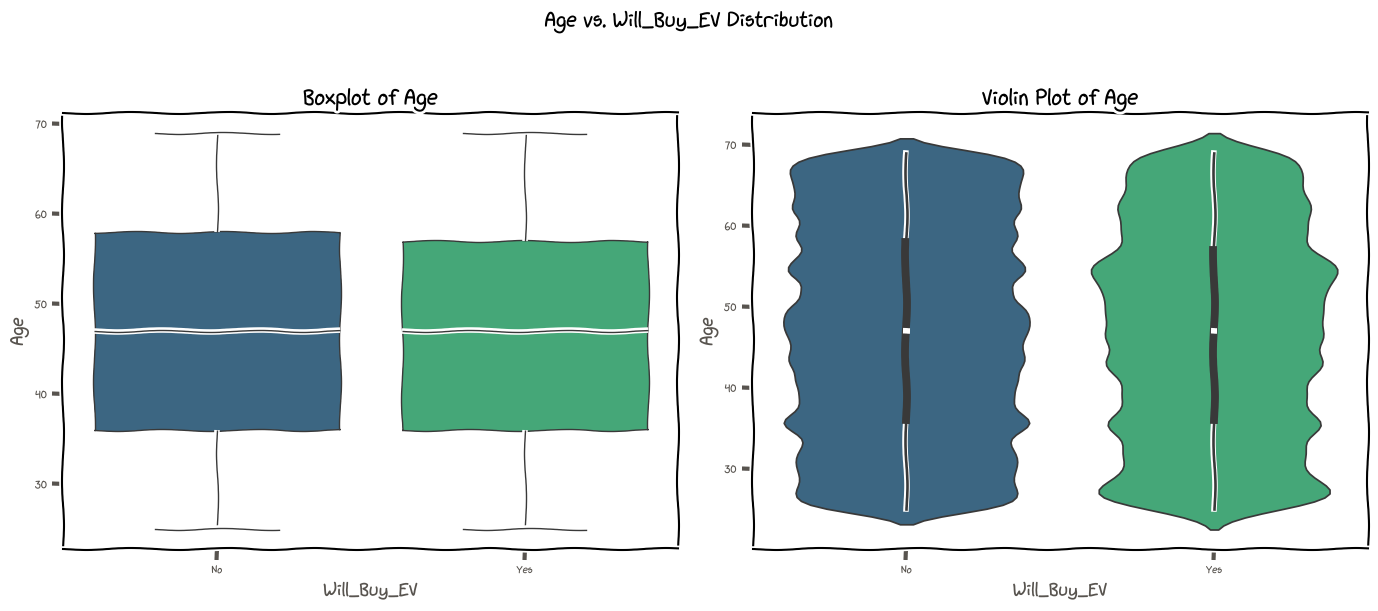

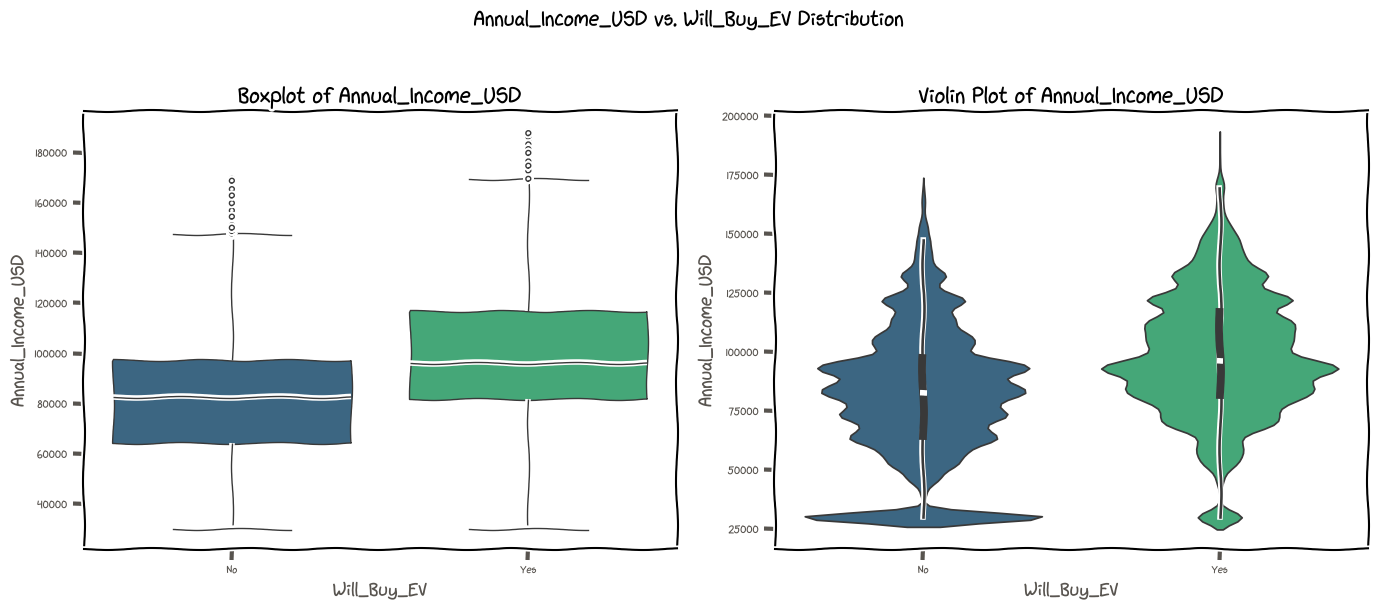

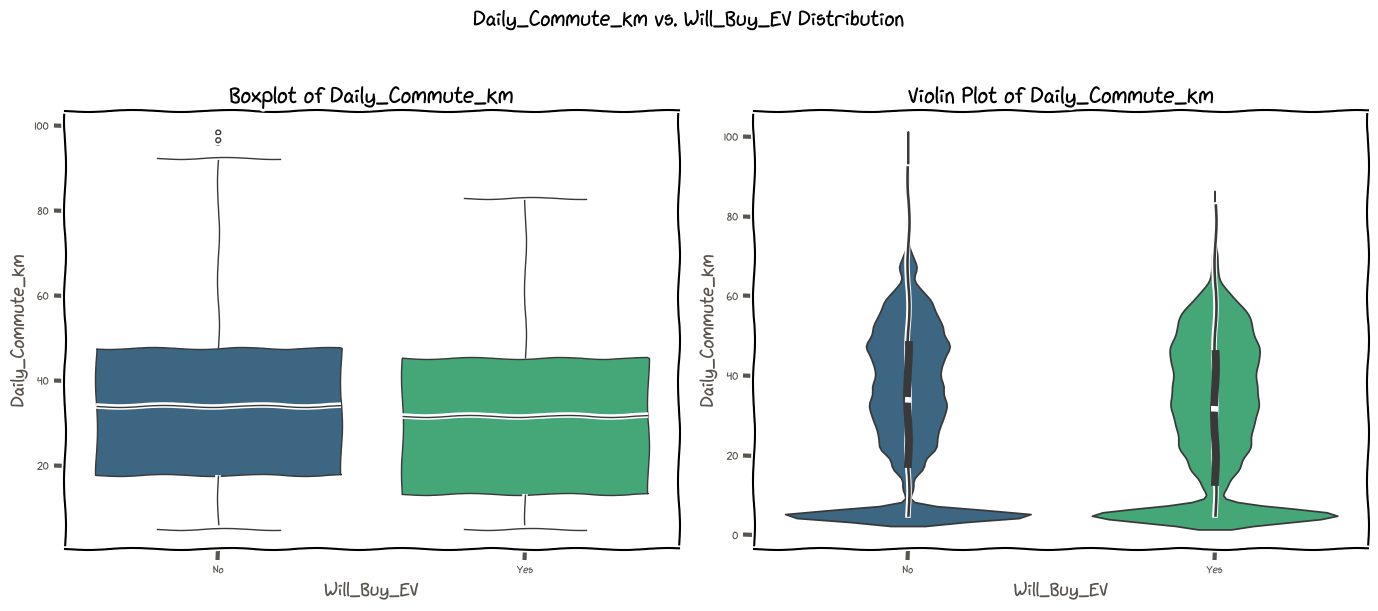

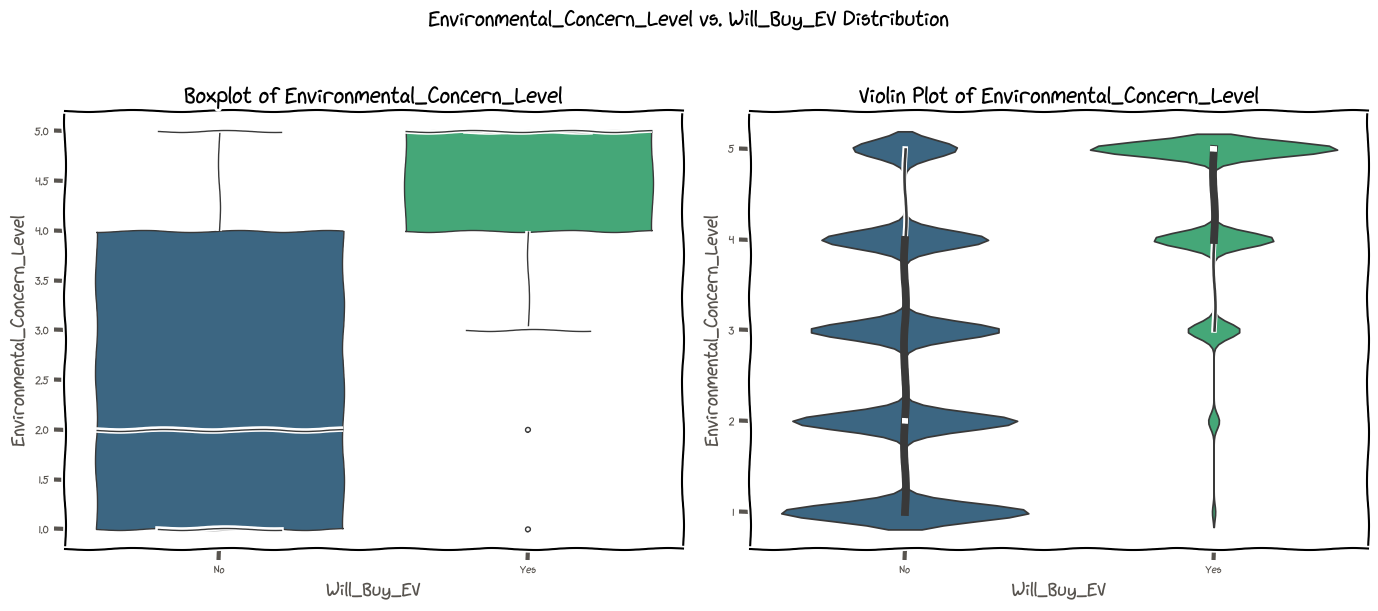

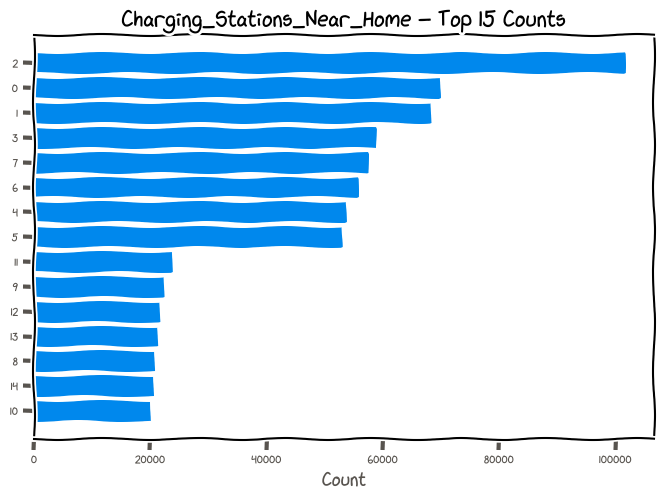

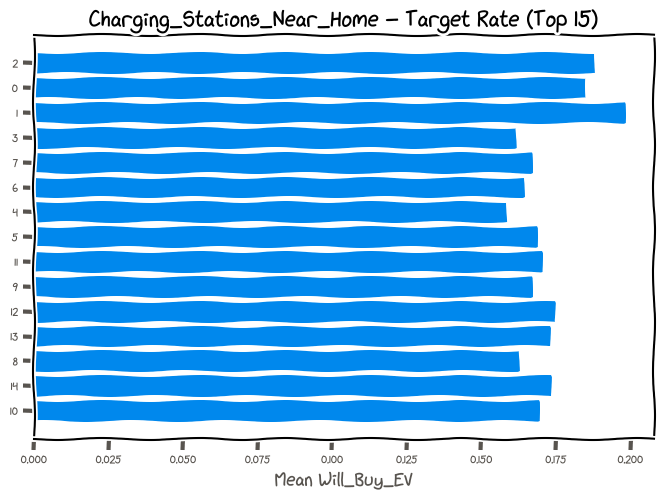

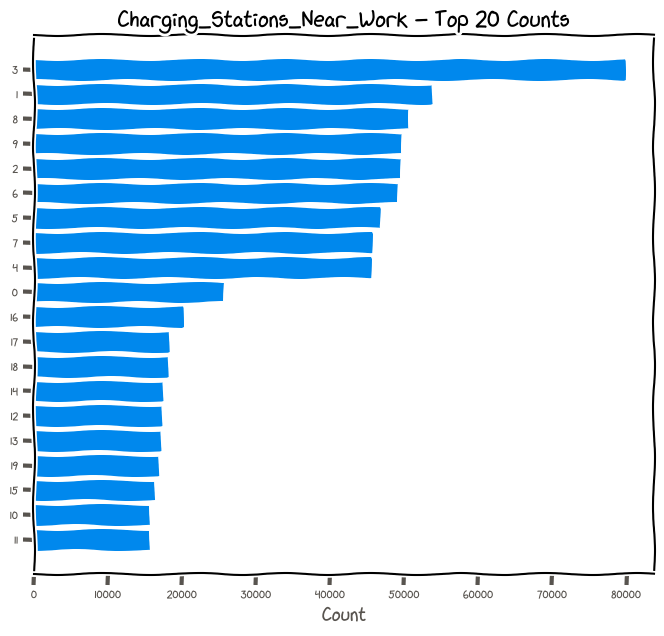

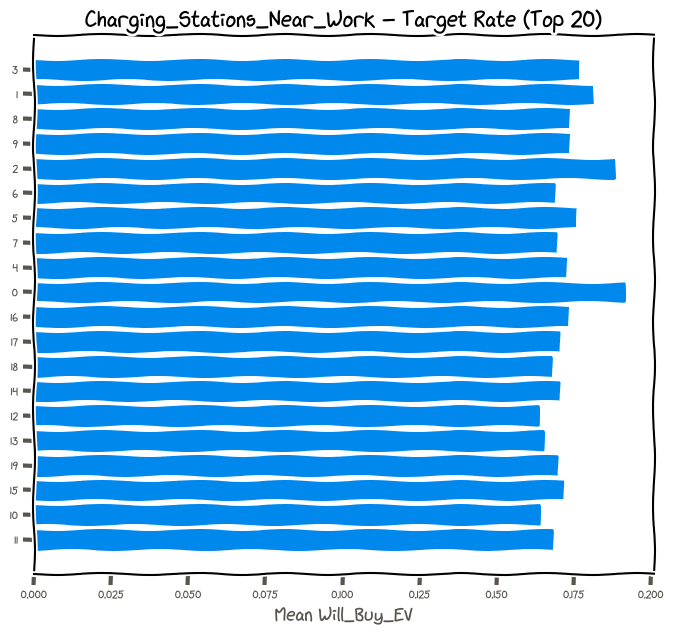

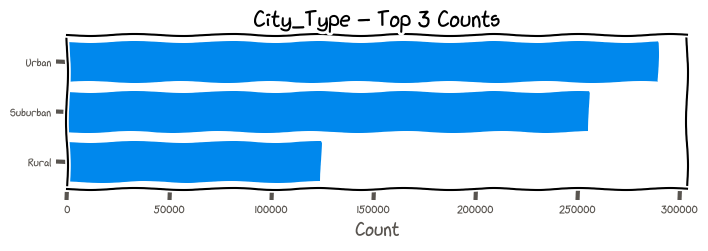

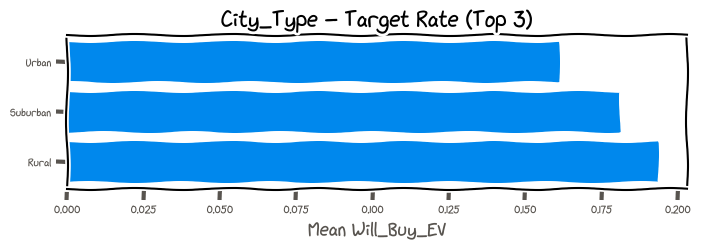

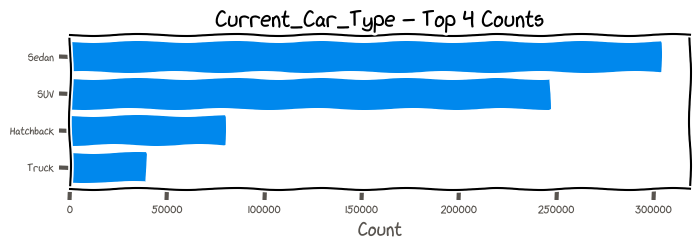

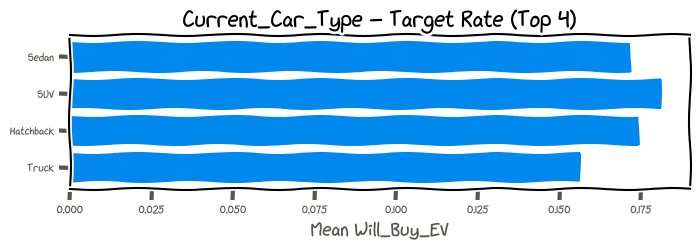

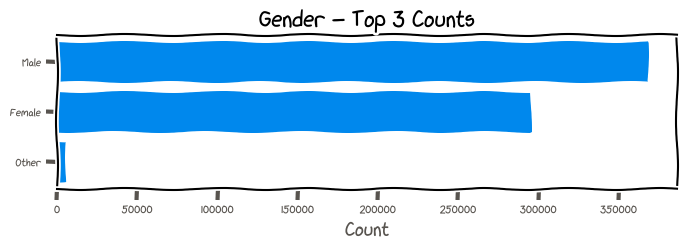

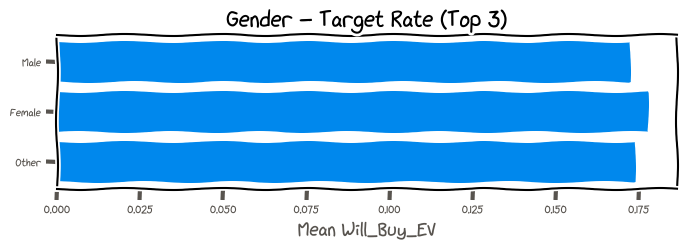

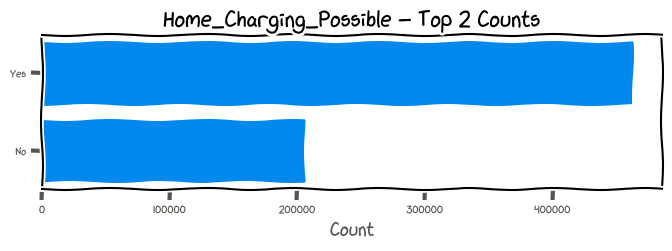

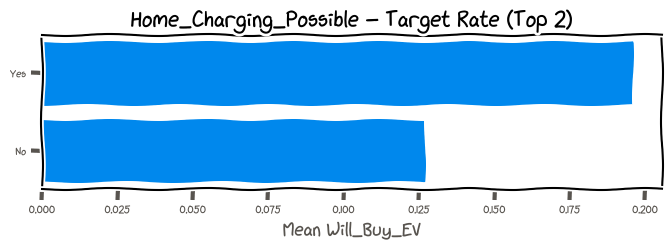

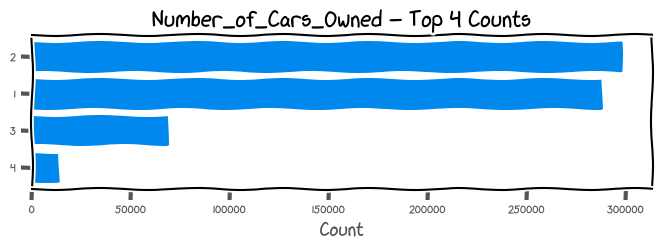

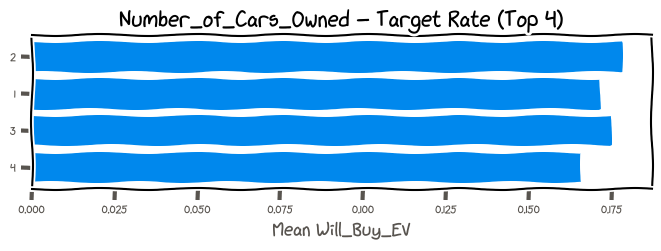

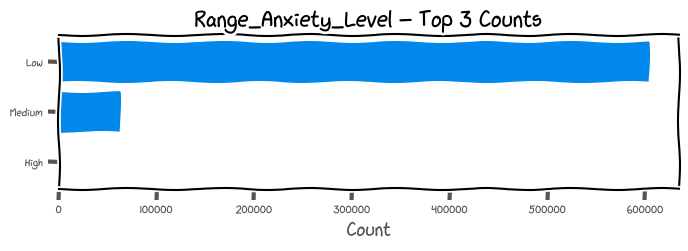

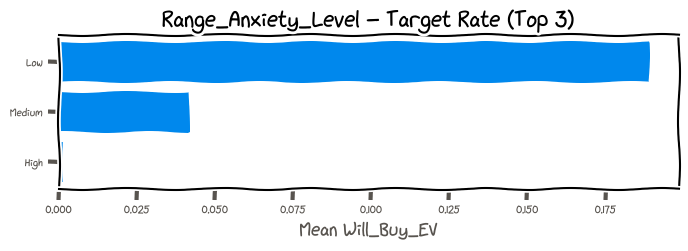

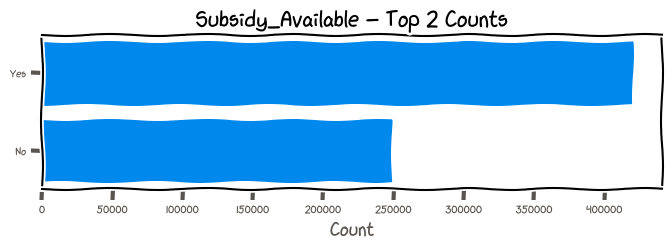

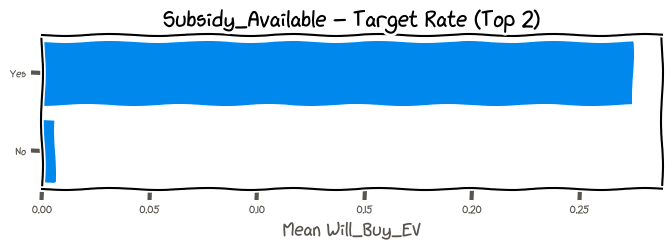

### Numeric x Category Trend

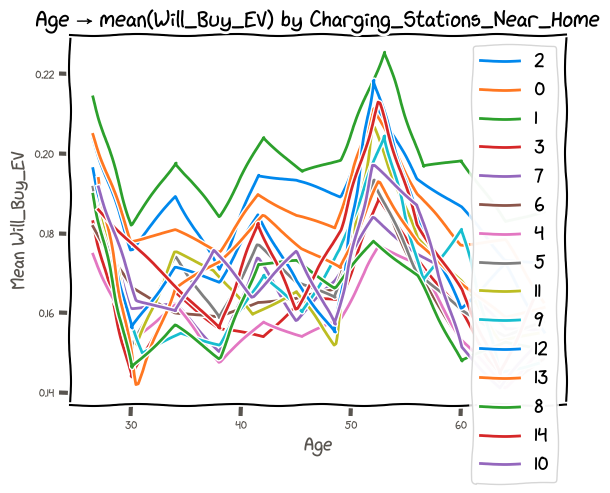

### Category x Category Trend

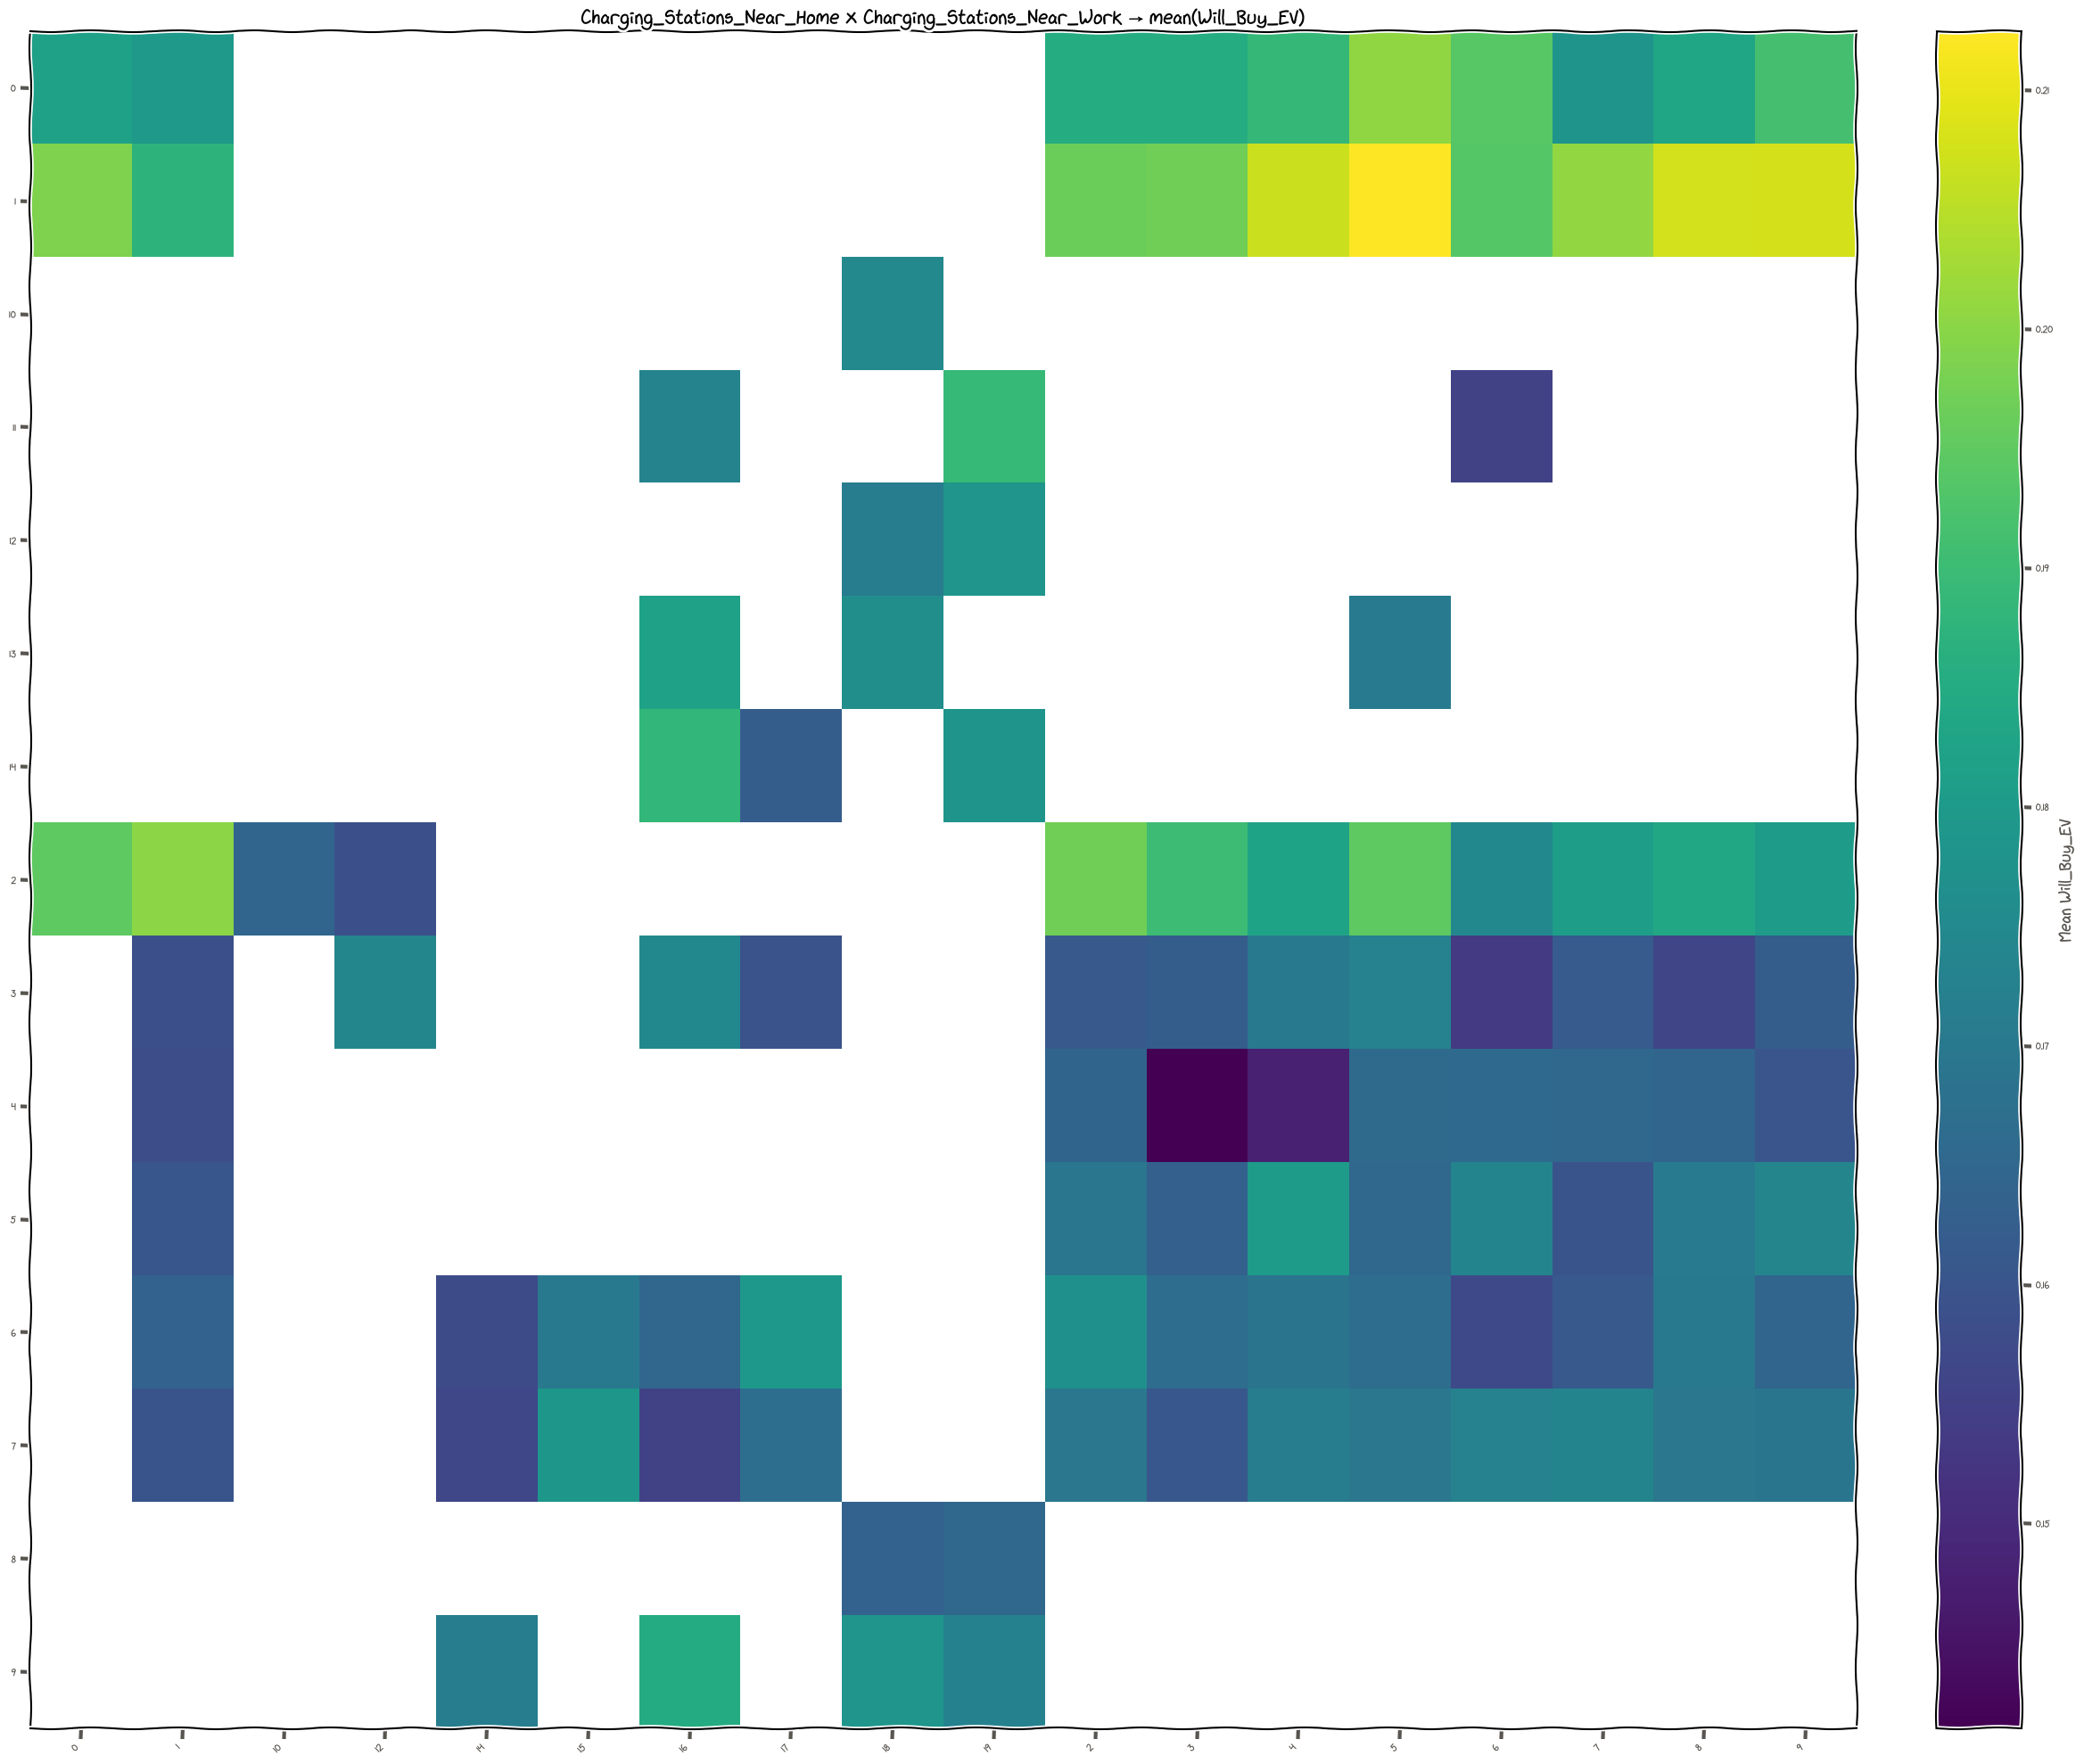

### Feature Signal Ranking

Top numeric (|Spearman|): [('Environmental_Concern_Level', 0.46120236908728146), ('Annual_Income_USD', 0.22415265825534658), ('Daily_Commute_km', -0.044621621096323866), ('Charging_Stations_Near_Home', -0.02098653422612362), ('Charging_Stations_Near_Work', -0.014002595740562696), ('Age', -0.007282048550072124), ('Number_of_Cars_Owned', 0.005679160170902565)]
Top categorical (range of mean target): [('Subsidy_Available', 0.26893858652004354, 2), ('Range_Anxiety_Level', 0.18765960921803101, 3), ('Home_Charging_Possible', 0.06873404063318866, 2), ('City_Type', 0.03233101771504571, 3), ('Current_Car_Type', 0.02453943832914493, 4), ('Gender', 0.00538866718359729, 3)]


In [9]:
setup.use_xkcd_style()

visualizer = DataVisualizer(target=TARGET, seed=setup.primary_seed())
visualizer.run_data_visualization(training_df)

### Correlation and Feature Signal Insights

1. **Dominant Numeric Signals**:
   * `Environmental_Concern_Level` (Spearman = **`0.4612`**): Strongest direct positive numerical driver.
   * `Annual_Income_USD` (Spearman = **`0.2242`**): Significant secondary positive correlation.
   * `Daily_Commute_km` (Spearman = **`-0.0446`**) and `Charging_Stations_Near_Home` (Spearman = **`-0.0210`**): Weak inverse correlations.

2. **Critical Categorical Rules / Gatekeepers**:
   * `Subsidy_Available`: High gatekeeper effect! When `No`, purchase rate is **`0.58%`** (virtually zero). When `Yes`, purchase rate jumps to **`27.47%`**.
   * `Range_Anxiety_Level`: High anxiety (`High`) drops purchase rate to **`0.14%`**. Medium anxiety drops rate to **`4.17%`**. Low anxiety yields **`18.90%`** purchase rate.
   * `Home_Charging_Possible`: `Yes` yields **`19.58%`** vs `No` yielding **`12.71%`**.

3. **Key Interaction Opportunities**:
   * Cross-interaction between `Subsidy_Available` and `Range_Anxiety_Level`: If `Subsidy_Available == Yes` AND `Range_Anxiety_Level == Low`, purchase rate reaches **`29.57%`**.

## 5. Visualizing Numerical Feature Distributions (Train vs Test)

Overlays KDE plots to visually confirm distribution matching across splits.

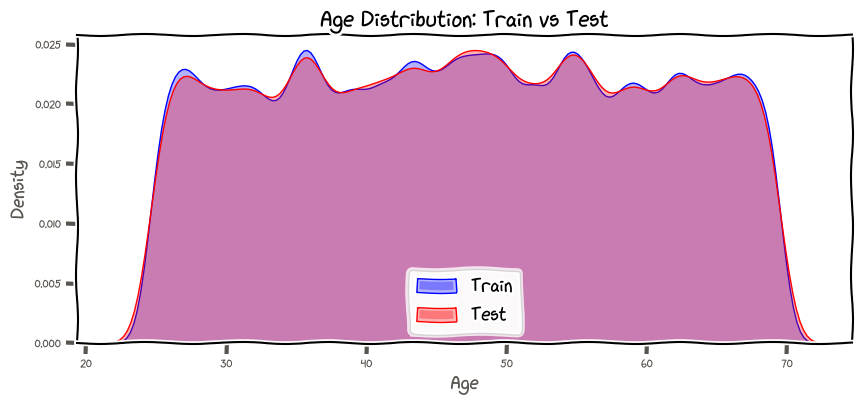

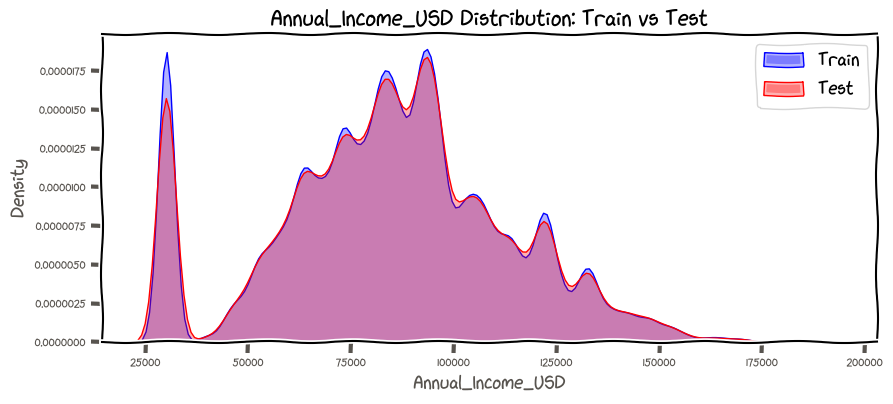

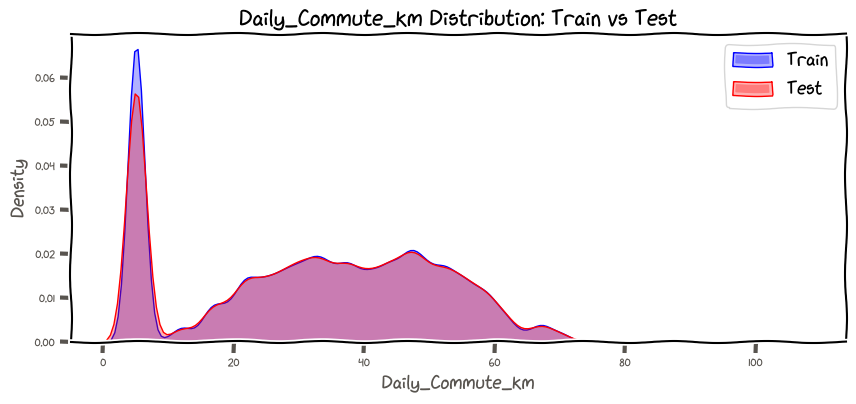

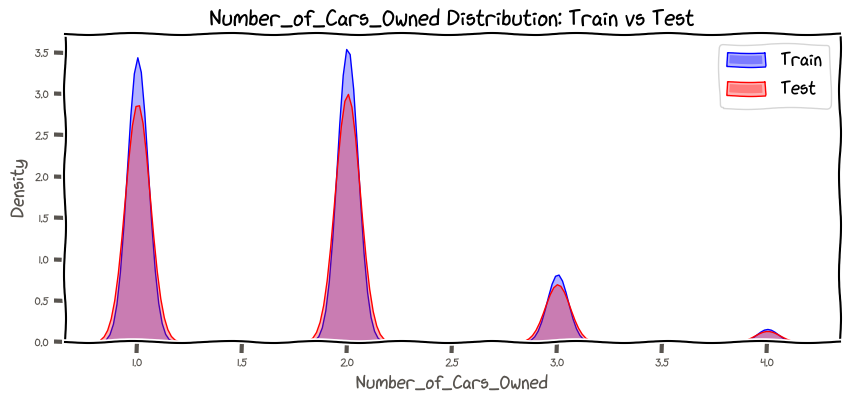

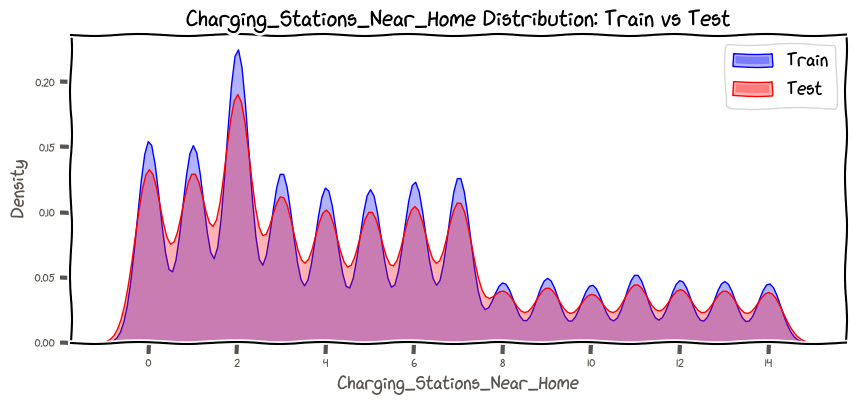

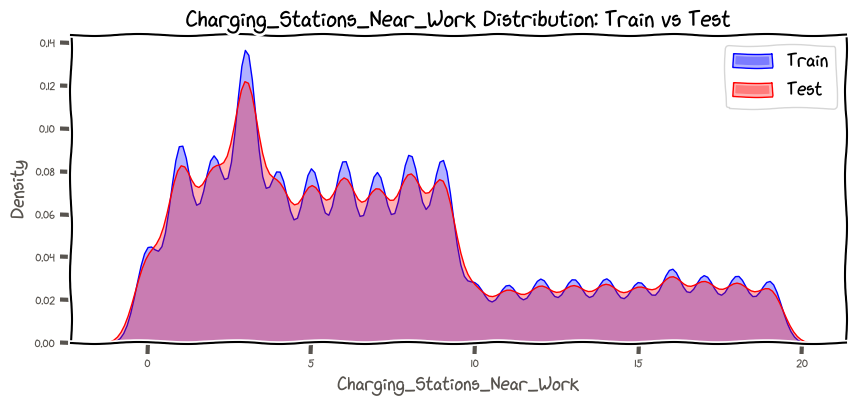

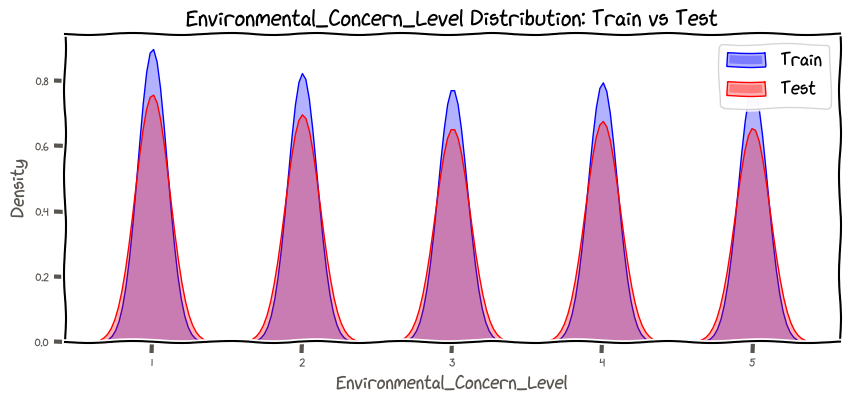

In [10]:
tops = [
    'Age',
    'Annual_Income_USD',
    'Daily_Commute_km',
    'Number_of_Cars_Owned',
    'Charging_Stations_Near_Home',
    'Charging_Stations_Near_Work',
    'Environmental_Concern_Level'
]
for top in tops:
    if top in training_df.columns and top in test_df.columns:
        plt.figure(figsize=(10, 4))
        sns.kdeplot(training_df[top].dropna(), label='Train', fill=True, color='blue', alpha=0.3)
        sns.kdeplot(test_df[top].dropna(), label='Test', fill=True, color='red', alpha=0.3)
        plt.title(f'{top} Distribution: Train vs Test')
        plt.xlabel(top)
        plt.ylabel('Density')
        plt.legend()
        plt.show()